<a href="https://colab.research.google.com/github/mickx79/An-lisis-de-publicaciones-de-X-para-tesis-de-grado/blob/main/An%C3%A1lisis_de_posteos_Tesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np


df = pd.read_excel('/content/dataframe_procesado.xlsx')

df.columns = df.columns.str.lower().str.replace(' ', '_')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   fecha                                    390 non-null    datetime64[ns]
 1   momento_clave                            390 non-null    object        
 2   usuario                                  390 non-null    object        
 3   texto_del_posteo                         390 non-null    object        
 4   likes                                    390 non-null    int64         
 5   retweets                                 390 non-null    int64         
 6   posición                                 390 non-null    object        
 7   promoción/apoyo_o_detracción/ataque      390 non-null    object        
 8   destinatario_de_la_promoción/detracción  390 non-null    object        
 9   uso_de_lenguaje_populista                39

In [ ]:
# Correción de datos erróneos

df.loc[7, 'promoción/apoyo_o_detracción/ataque'] = 'PROMOCIÓN'
df.loc[7, 'emoción_predominante'] = 'FELICIDAD'

df.loc[66, 'destinatario_de_la_promoción/detracción'] = 'ENDOGRUPO'

df.loc[355, 'promoción/apoyo_o_detracción/ataque'] = 'DETRACCIÓN'
df.loc[355, 'destinatario_de_la_promoción/detracción'] = 'EXOGRUPO'

df.loc[27, 'promoción/apoyo_o_detracción/ataque'] = 'DETRACCIÓN'
df.loc[27, 'destinatario_de_la_promoción/detracción'] = 'EXOGRUPO'
df.loc[27, 'emoción_predominante'] = 'ENOJO/INDIGNACIÓN'

df.loc[110, 'emoción_predominante'] = 'FELICIDAD'

df.loc[109, 'emoción_predominante'] = 'FELICIDAD'

df.loc[121, 'emoción_predominante'] = 'FELICIDAD'

df.loc[257, 'destinatario_de_la_promoción/detracción'] = 'ENDOGRUPO'

df.loc[258, 'destinatario_de_la_promoción/detracción'] = 'ENDOGRUPO'

df.loc[274, 'destinatario_de_la_promoción/detracción'] = 'REFERENTE CONTRARIO'

df.loc[276, 'destinatario_de_la_promoción/detracción'] = 'REFERENTE CONTRARIO'

df.loc[304, 'emoción_predominante'] = 'ASCO'
df.loc[276, 'destinatario_de_la_promoción/detracción'] = 'EXOGRUPO'

df.loc[157, 'destinatario_de_la_promoción/detracción'] = 'REFERENTE CONTRARIO'


df.loc[387, 'destinatario_de_la_promoción/detracción'] = 'EXOGRUPO'

--- Fila 7 modificada ---


,fecha,momento_clave,usuario,texto_del_posteo,likes,retweets,posición,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
7,2023-06-25,Campaña presidencial 2023,@CortasLa,"hermoso ver cómo Schiaretti, ninguneado por bu...",955,270,Peronista,PROMOCIÓN,ENDOGRUPO,False,True,True,EMOCIONAL,False,False,FELICIDAD



--- Fila 355 modificada ---


,fecha,momento_clave,usuario,texto_del_posteo,likes,retweets,posición,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
355,2025-09-02,Campaña legislativa 2025,@etupito\n,Que difícil van a ser estas elecciones del dom...,4800,1200,Peronista,DETRACCIÓN,EXOGRUPO,False,False,False,LÓGICA,True,False,ASCO


--- Fila 27 modificada ---


...

,fecha,momento_clave,usuario,texto_del_posteo,likes,retweets,posición,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
304,2025-03-22,Segundo año de gestión presidencial 2025,@feminstina\n,No puedo creer que exista gente que escuche ha...,13000,1300,Peronista,DETRACCIÓN,EXOGRUPO,False,False,False,EMOCIONAL,False,False,ASCO


--- Fila 157 modificada ---


,fecha,momento_clave,usuario,texto_del_posteo,likes,retweets,posición,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
157,2024-02-02,Primer año de gestión presidencial 2024,@GabrielSoglio1\n,Sueldo promedio de un investigador del CONICET...,23000,7900,Peronista,DETRACCIÓN,REFERENTE CONTRARIO,False,False,False,EMOCIONAL,True,False,ENOJO/INDIGNACIÓN


--- Fila 387 modificada ---


,fecha,momento_clave,usuario,texto_del_posteo,likes,retweets,posición,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
387,2025-10-26,Campaña legislativa 2025,@reZil_fr\n,si votaste a LLA posiblemente seas:\n-Adolesce...,29000,4600,Peronista,DETRACCIÓN,EXOGRUPO,True,True,True,EMOCIONAL,True,True,ENOJO/INDIGNACIÓN


# Cantidad de usuarios y división de posteos

In [ ]:
cantidad_peronistas = df['posición'].value_counts()
print(cantidad_peronistas)

posición
Antiperonista    225
Peronista        165
Name: count, dtype: int64


In [ ]:
cantidad_usuarios = df['usuario'].value_counts()
print(cantidad_usuarios)

usuario
@inakiigutierrez\n    7
@Trumperizar\n        6
@maquialifraco\n      6
@crypto_degen27\n     6
@DianaMondino         6
                     ..
@Kout_of_Context\n    1
@Juanolitico\n        1
@zxvgxl\n             1
@Crioshito            1
@Cris_noticias\n      1
Name: count, Length: 270, dtype: int64


In [ ]:
# Agrupamos por usuario y posición para obtener la cantidad de posteos y asegurarnos de ver su bando político
top_usuarios = (
    df.groupby(['usuario', 'posición'])
    .size()
    .reset_index(name='cantidad_posts')
    .sort_values(by='cantidad_posts', ascending=False)
)

# Mostramos el Top 20 de cuentas con más actividad en todo el corpus
print('--- TOP 20 CUENTAS CON MÁS POSTEOS ---')
print(top_usuarios.head(20).to_string(index=False))

--- TOP 20 CUENTAS CON MÁS POSTEOS ---
           usuario      posición  cantidad_posts
@inakiigutierrez\n Antiperonista               7
 @crypto_degen27\n Antiperonista               6
  @maquialifraco\n Antiperonista               6
     @DianaMondino Antiperonista               6
    @Trumperizar\n Antiperonista               6
   @PatoBullrich\n Antiperonista               5
  @inakiigutierrez Antiperonista               5
       @usdtermo\n Antiperonista               5
    @therealbuni\n Antiperonista               5
 @TommyShelby_30\n Antiperonista               4
         @usdtermo Antiperonista               4
       @TugoNews\n     Peronista               4
       @Pampa139\n     Peronista               4
        @LaKusama_     Peronista               4
         @Pampa139     Peronista               4
    @ElTrumpista\n Antiperonista               4
  @PERIODlSTAPERON     Peronista               3
  @Miguel_Boggiano Antiperonista               3
       @jlespert\n Antiperonis

## División del dataframe original en los 4 períodos

In [ ]:

df_campana_2023 = df[df['momento_clave'] == 'Campaña presidencial 2023']
df_gestion_2024 = df[df['momento_clave'] == 'Primer año de gestión presidencial 2024']
df_gestion_2025 = df[df['momento_clave'] == 'Segundo año de gestión presidencial 2025']
df_campana_2025 = df[df['momento_clave'] == 'Campaña legislativa 2025']

In [ ]:
total_2023 = len(df_campana_2023)
total_2024 = len(df_gestion_2024)
total_2025 = len(df_gestion_2025)
total_2025_b = len(df_campana_2025)

print(f"Total de 2023: {total_2023}")
print(f"Total de 2024: {total_2024}")
print(f"Total de 2025: {total_2025}")
print(f"Total de 2025 (B): {total_2025_b}")

Total de 2023: 105
Total de 2024: 165
Total de 2025: 75
Total de 2025 (B): 45


In [ ]:
# Comprobación de filas
total_original = len(df)
total_separados = len(df_campana_2023) + len(df_gestion_2024) + len(df_gestion_2025) + len(df_campana_2025)

print(f"Filas originales: {total_original}")
print(f"Filas tras la separación: {total_separados}")

if total_original == total_separados:
    print("¡Separación exitosa! No se perdió ningún dato.")
else:
    print("Cuidado: Hay una diferencia. Revisá si hay valores nulos o mal escritos en la columna.")

Filas originales: 390
Filas tras la separación: 390
¡Separación exitosa! No se perdió ningún dato.


# **Transversales**

## Cantidad de usuarios

In [ ]:
# Conteo de frecuencia por cada usuario
conteo_usuarios = df['usuario'].value_counts()

# Cantidad total de registros y cantidad de usuarios únicos
total_registros = len(df['usuario'])
usuarios_unicos = df['usuario'].nunique()
usuarios_repetidos = total_registros - usuarios_unicos

print(f"--- ANÁLISIS DE USUARIOS ---")
print(f"Total de posteos/registros: {total_registros}")
print(f"Cantidad de usuarios únicos: {usuarios_unicos}")
print(f"Registros de usuarios repetidos: {usuarios_repetidos}\n")

print("Top 10 de usuarios con más apariciones:")
print(conteo_usuarios.head(10))

--- ANÁLISIS DE USUARIOS ---
Total de posteos/registros: 390
Cantidad de usuarios únicos: 270
Registros de usuarios repetidos: 120

Top 10 de usuarios con más apariciones:
usuario
@inakiigutierrez\n    7
@Trumperizar\n        6
@maquialifraco\n      6
@crypto_degen27\n     6
@DianaMondino         6
@usdtermo\n           5
@inakiigutierrez      5
@PatoBullrich\n       5
@therealbuni\n        5
@TommyShelby_30\n     4
Name: count, dtype: int64


## Cantidad de likes y retweets por espacio

In [ ]:
# Nos aseguramos de trabajar con una copia del DataFrame original
df_original = df.copy()

# Limpiamos los nombres de las columnas por las dudas (espacios en blanco, minúsculas, etc.)
df_original.columns = df_original.columns.str.strip().str.lower()

# Verificamos y sumamos los likes y retweets agrupados por posición política
# Asegurate de que los nombres de las columnas de likes y retweets coincidan con los de tu df
metricas_espacio = df_original.groupby('posición')[['likes', 'retweets']].sum()

# Opcional: Si querés sumar ambos para tener un total de "engagement" por espacio
metricas_espacio['engagement_total'] = metricas_espacio['likes'] + metricas_espacio['retweets']

print("Suma total de interacciones por espacio político:")
display(metricas_espacio)

Suma total de interacciones por espacio político:


,likes,retweets,engagement_total
posición,,,
Antiperonista,6026600,1367677,7394277
Peronista,4394655,914108,5308763


## Promedio de likes y retweets por espacio

In [ ]:
# Trabajamos con una copia del DataFrame original
df_original = df.copy()
df_original.columns = df_original.columns.str.strip().str.lower()

# Calculamos el promedio (media) de likes y retweets agrupados por posición política
promedios_espacio = df_original.groupby('posición')[['likes', 'retweets']].mean()

# Opcional: Redondear los decimales para que la tabla quede más prolija para la tesis
promedios_espacio = promedios_espacio.round(2)

print("Promedio de interacciones por posteo según espacio político:")
display(promedios_espacio)

Promedio de interacciones por posteo según espacio político:


,likes,retweets
posición,,
Antiperonista,26784.89,6078.56
Peronista,26634.27,5540.05


## Caracterización de los posteos mas likeados

In [ ]:

# 1. Copiamos y limpiamos nombres de columnas del DataFrame original
df_carac = df.copy()
df_carac.columns = df_carac.columns.str.strip().str.lower()

# Asegurar que la columna de likes sea numérica
df_carac['likes'] = pd.to_numeric(df_carac['likes'], errors='coerce')

# 2. Ordenamos por likes de mayor a menor dentro de cada posición y tomamos los primeros 3 de cada grupo
df_top_likes = (
    df_carac.sort_values(['posición', 'likes'], ascending=[True, False])
    .groupby('posición')
    .head(3)
)

# 3. Seleccionamos las columnas de interés para la caracterización
columnas_analisis = [
    'posición',
    'likes',
    'retweets',
    'texto_del_posteo',  # Ajustado al nombre real que mostraste en tus columnas previas
    'promoción/apoyo_o_detracción/ataque',
    'destinatario_de_la_promoción/detracción',
    'uso_de_lenguaje_populista',
    'uso_de_palabras_malsonantes',
    'uso_de_etiquetas_peyorativas',
    'tipo_de_microargumentación',
    'uso_del_humor_o_ironía',
    'repite_estereotipos_negativos',
    'emoción_predominante'
]

# Ajustamos los nombres según existan exactamente en tu df
columnas_existentes = [col for col in columnas_analisis if col in df_carac.columns]

# Mostramos los resultados en detalle para la tesis
print("Caracterización de los 3 posteos más likeados por espacio político:")
top_caracterizacion = df_top_likes[columnas_existentes]

# Configuramos pandas para que no corte el texto y se lea bien
pd.set_option('display.max_colwidth', None)
display(top_caracterizacion)

Caracterización de los 3 posteos más likeados por espacio político:


,posición,likes,retweets,texto_del_posteo,promoción/apoyo_o_detracción/ataque,destinatario_de_la_promoción/detracción,uso_de_lenguaje_populista,uso_de_palabras_malsonantes,uso_de_etiquetas_peyorativas,tipo_de_microargumentación,uso_del_humor_o_ironía,repite_estereotipos_negativos,emoción_predominante
94,Antiperonista,211000,34000,VIVA LA LIBERTAD CARAJO,PROMOCIÓN,ENDOGRUPO,False,True,False,EMOCIONAL,False,False,FELICIDAD
101,Antiperonista,198000,33000,El Kirchnerismo llega a su fin.,DETRACCIÓN,EXOGRUPO,False,False,False,EMOCIONAL,False,False,FELICIDAD
117,Antiperonista,115000,17000,Felicitaciones Presidente Milei! No le sacaría ni una sola coma a su discurso en el Congreso. No puedo estar más de acuerdo con sus palabras de hoy.,PROMOCIÓN,REFERENTE PROPIO,False,False,False,EMOCIONAL,False,False,FELICIDAD
293,Peronista,106000,25000,Mira lo que es esta foto hermano\nQUE MIERDA VOTARON (Foto adjunta),DETRACCIÓN,EXOGRUPO,False,True,False,EMOCIONAL,False,False,ENOJO/INDIGNACIÓN
301,Peronista,106000,22000,"Te chupaban. Te electrocutaban los genitales. Te los cortaban. Te los quemaban. Introducian ratas por el ano o la vagina ""el rectoscopio"" para que te comieran por dentro. Te violaban. Te robaban a tus hijos. Te tiraban atado desde un avión. Hijos de puta. Ningún olvido ni perdón",DETRACCIÓN,EXOGRUPO,False,True,False,EMOCIONAL,False,False,ENOJO/INDIGNACIÓN
286,Peronista,78000,16000,El niño de la imagen se llama Lautaro. Tiene 12 años. Ayer fue detenido por la policía de Bullrich y Milei cuando salía del colegio. Se desvío buscando dónde tomar el colectivo que no pasaba porque estaban las calles cortadas.,DETRACCIÓN,EXOGRUPO,False,False,False,EMOCIONAL,False,False,ENOJO/INDIGNACIÓN


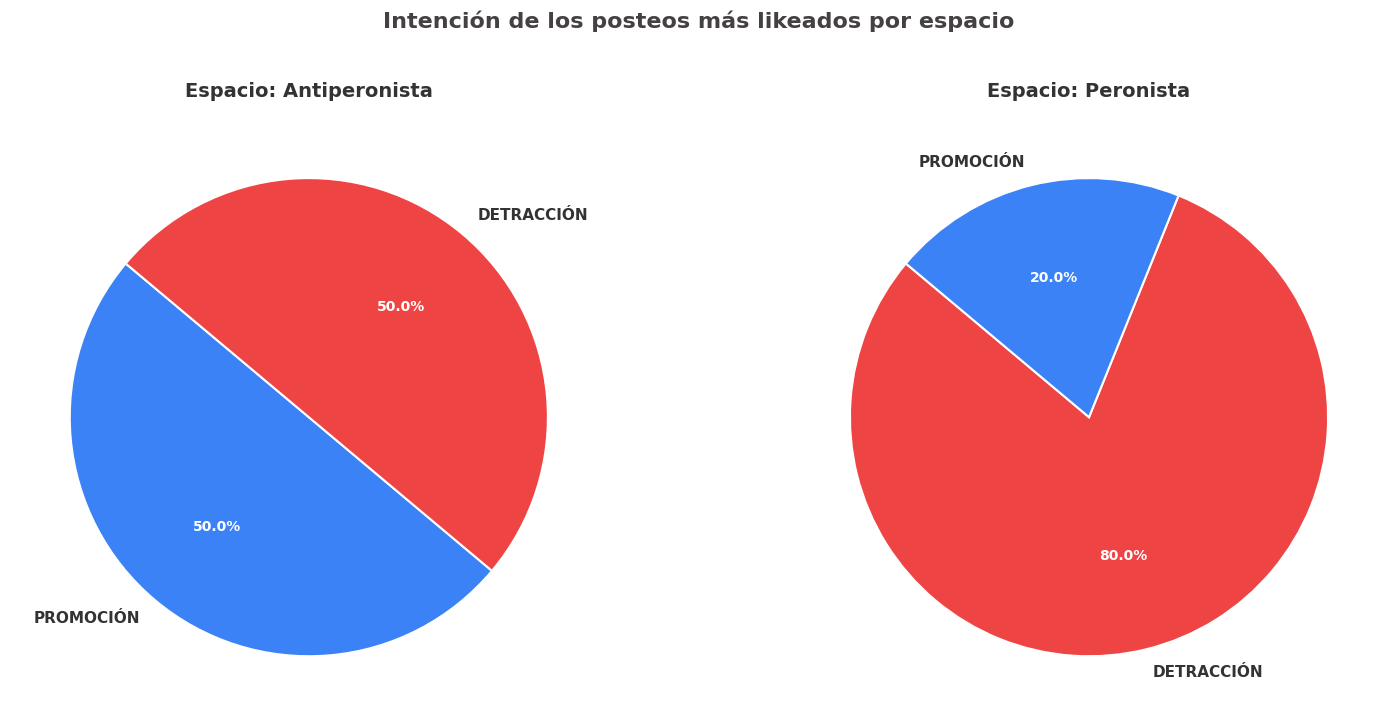


--- Tabla resumen: Emoción y Tipo de Discurso en el Top 10 de más likeados ---


,posición,likes,promoción/apoyo_o_detracción/ataque,emoción_predominante,texto_del_posteo
0,Antiperonista,211000,PROMOCIÓN,FELICIDAD,VIVA LA LIBERTAD CARAJO
1,Antiperonista,198000,DETRACCIÓN,FELICIDAD,El Kirchnerismo llega a su fin.
2,Antiperonista,115000,PROMOCIÓN,FELICIDAD,Felicitaciones Presidente Milei! No le sacaría ni una sola coma a su discurso en el Congreso. No puedo estar más de acuerdo con sus palabras de hoy.
3,Antiperonista,76000,DETRACCIÓN,FURIA,"Te encerraron con una cuarentena récord, te fundieron sin dejarte trabajar, se juntaban en Olivos a tus espaldas, se afanaron las vacunas, llevaron el dólar a $1200, llevaron la inflación a más de un 100% anual y la pobreza a un 50%. Los votaste igual. Te merecés comer mierda."
4,Antiperonista,73000,PROMOCIÓN,FELICIDAD,ES EXACTAMENTE LO QUE VOTEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE (Foto adjunta)
5,Antiperonista,72000,DETRACCIÓN,ASCO,"Hay gente que no llega a fin de mes que votó para Presidente al Ministro de Economía responsable de que no llegue a fin de mes. Argentina, no lo entenderías."
6,Antiperonista,70000,DETRACCIÓN,ENOJO/INDIGNACIÓN,"Mi abuela paterna falleció en tiempos de Cristina, esperando una silla de ruedas que nunca llegó de Pami. Cuando asumió Macri auditaron y encontraron un galpón lleno de esas sillas sin entregar. No me vengan con que les importan los jubilados, manga de forros, nunca le importaron"
7,Antiperonista,68000,DETRACCIÓN,ENOJO/INDIGNACIÓN,Atentaron contra la Casa Rosada utilizando las piedras que recordaban a los fallecidos por la pandemia. Los violentos no tienen el más mínimo respeto por nada. Fin.
8,Antiperonista,65000,PROMOCIÓN,FELICIDAD,"Fin del kirchnerismo\n\nCristina de espalda al pueblo, insultando a los laburantes.\n\nGracias Milei por tanto."
9,Antiperonista,65000,PROMOCIÓN,FELICIDAD,"Algunos miles parando, algunos millones trabajando.\n\nFin."


In [ ]:

# 1. Copiamos y limpiamos el DataFrame
df_vis = df.copy()
df_vis.columns = df_vis.columns.str.strip().str.lower()

# Asegurarnos que likes sea numérico para el filtro
df_vis['likes'] = pd.to_numeric(df_vis['likes'], errors='coerce')
df_vis['likes'] = df_vis['likes'].fillna(0)

# Unificamos variantes de alegría en felicidad por consistencia
if 'emoción_predominante' in df_vis.columns:
    df_vis['emoción_predominante'] = df_vis['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# 2. Filtramos los Top 10 tweets más likeados de cada espacio político
top_10_por_posicion = (
    df_vis.sort_values(['posición', 'likes'], ascending=[True, False])
    .groupby('posición')
    .head(10)
)

col_tipo = 'promoción/apoyo_o_detracción/ataque'
col_emocion = 'emoción_predominante'

# Verificamos que la columna exista antes de graficar
if col_tipo not in top_10_por_posicion.columns:
    print(f"Error: La columna '{col_tipo}' no se encuentra en el DataFrame.")
    print(f"Columnas disponibles: {list(top_10_por_posicion.columns)}")
else:
    posiciones = top_10_por_posicion['posición'].dropna().unique()

    # Creamos una figura con 2 subplots lado a lado
    fig, axes = plt.subplots(1, len(posiciones), figsize=(16, 7))
    if len(posiciones) == 1:
        axes = [axes]

    # Diccionario de colores fijos para cada categoría de la columna
    # (Podés ajustar los nombres de las claves exactas según los valores reales que tenga tu columna)
    mapa_colores = {
        'promoción': '#3b82f6',     # Azul
        'apoyo': '#10b981',         # Verde
        'detracción': '#ef4444',     # Rojo
        'ataque': '#ef4444'         # Rojo
    }

    for i, posicion in enumerate(posiciones):
        ax = axes[i]

        # Filtramos los datos del espacio político actual
        df_pos = top_10_por_posicion[top_10_por_posicion['posición'] == posicion]

        # Contamos las frecuencias
        conteo = df_pos[col_tipo].value_counts()

        if not conteo.empty:
            # Asignamos el color fijo a cada categoría presente (si alguna no está en el diccionario, usa un gris por defecto)
            colores_actuales = [mapa_colores.get(str(cat).lower().strip(), '#9ca3af') for cat in conteo.index]

            # Gráfico de torta (pie chart)
            wedges, texts, autotexts = ax.pie(
                conteo,
                labels=conteo.index,
                autopct='%1.1f%%',
                startangle=140,
                colors=colores_actuales,
                wedgeprops=dict(edgecolor='#ffffff', linewidth=1.5)
            )

            # Estilo de los textos
            plt.setp(autotexts, size=10, weight="bold", color="white")
            plt.setp(texts, size=11, weight="bold", color='#333333')

        ax.set_title(f'Espacio: {str(posicion).capitalize()}', fontsize=14, pad=15, fontweight='bold', color='#333333')

    # Título general de la figura
    fig.suptitle('Intención de los posteos más likeados por espacio', fontsize=16, fontweight='bold', color='#444140', y=1.03)

    plt.tight_layout()
    plt.show()

    # Tabla resumen en consola
    print("\n--- Tabla resumen: Emoción y Tipo de Discurso en el Top 10 de más likeados ---")
    columnas_a_mostrar = ['posición', 'likes', col_tipo, col_emocion]
    texto_col = 'texto_del_posteo' if 'texto_del_posteo' in top_10_por_posicion.columns else ('texto' if 'texto' in top_10_por_posicion.columns else None)
    if texto_col:
        columnas_a_mostrar.append(texto_col)

    resumen_top = top_10_por_posicion[columnas_a_mostrar]
    display(resumen_top.reset_index(drop=True))

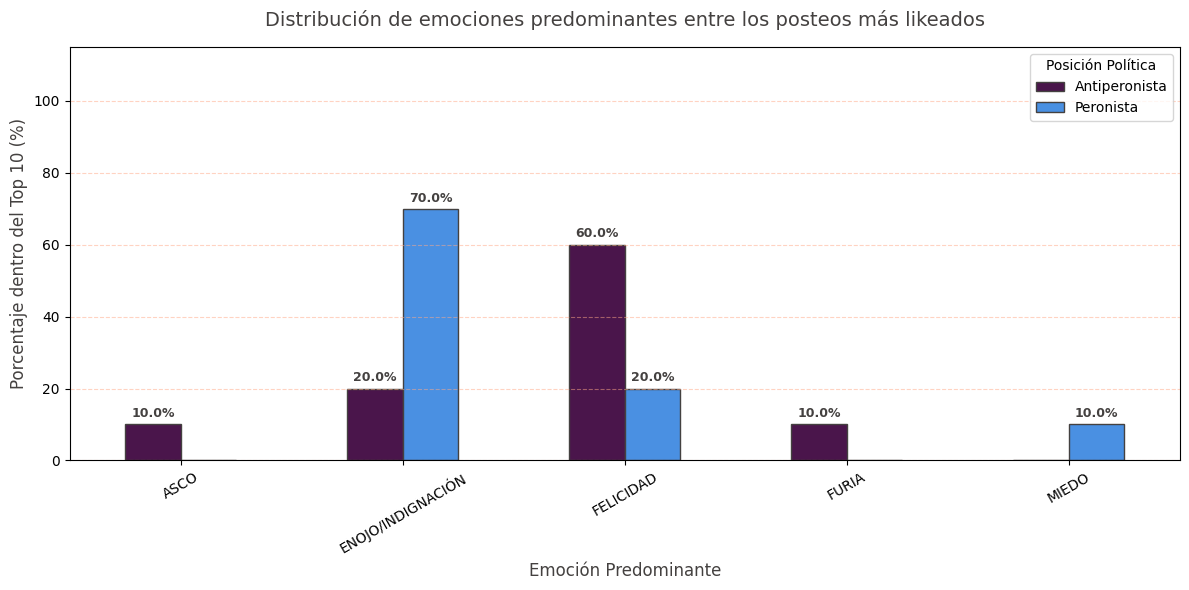

In [ ]:
# 1. Copiamos y limpiamos el DataFrame
df_vis = df.copy()
df_vis.columns = df_vis.columns.str.strip().str.lower()
df_vis['likes'] = pd.to_numeric(df_vis['likes'], errors='coerce')

# Unificamos variantes de alegría en felicidad
if 'emoción_predominante' in df_vis.columns:
    df_vis['emoción_predominante'] = df_vis['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# 2. Filtramos los Top 10 tweets más likeados de cada espacio político
top_10_por_posicion = (
    df_vis.sort_values(['posición', 'likes'], ascending=[True, False])
    .groupby('posición')
    .head(10)
)

col_emocion = 'emoción_predominante'

# 3. Creamos la tabla cruzada en porcentajes (normalizada por cada posición) para las emociones
tabla_porcentual_emociones = pd.crosstab(
    top_10_por_posicion[col_emocion],
    top_10_por_posicion['posición'],
    normalize='columns'
) * 100

# 4. Definimos los colores característicos para cada bloque político
colores_bloques = ['#4a154b', '#4a90e2']

# 5. Gráfico de barras porcentual (0 a 100%) con colores definidos
ax = tabla_porcentual_emociones.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_bloques,
    edgecolor='#444140',
    linewidth=1,
    rot=30
)

# --- NUEVO: Agregar etiquetas de porcentaje arriba de cada barra ---
for container in ax.containers:
    # Recogemos la altura (porcentaje) de cada barra
    heights = [bar.get_height() for bar in container]

    # Formateamos la etiqueta añadiendo el signo '%' (si es mayor a 0 para no saturar)
    labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

    # Colocamos las etiquetas sobre las barras
    ax.bar_label(
        container,
        labels=labels,
        padding=3,
        fontsize=9,
        color='#444140',
        fontweight='bold',
        rotation=0
    )
# ------------------------------------------------------------------

plt.title('Distribución de emociones predominantes entre los posteos más likeados', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje dentro del Top 10 (%)', fontsize=12, color='#444140')

# Extendemos un poco el límite superior del eje Y para que las etiquetas no toquen el borde superior
plt.ylim(0, 115)

plt.legend(title='Posición Política', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

## Tipo de microargumentación

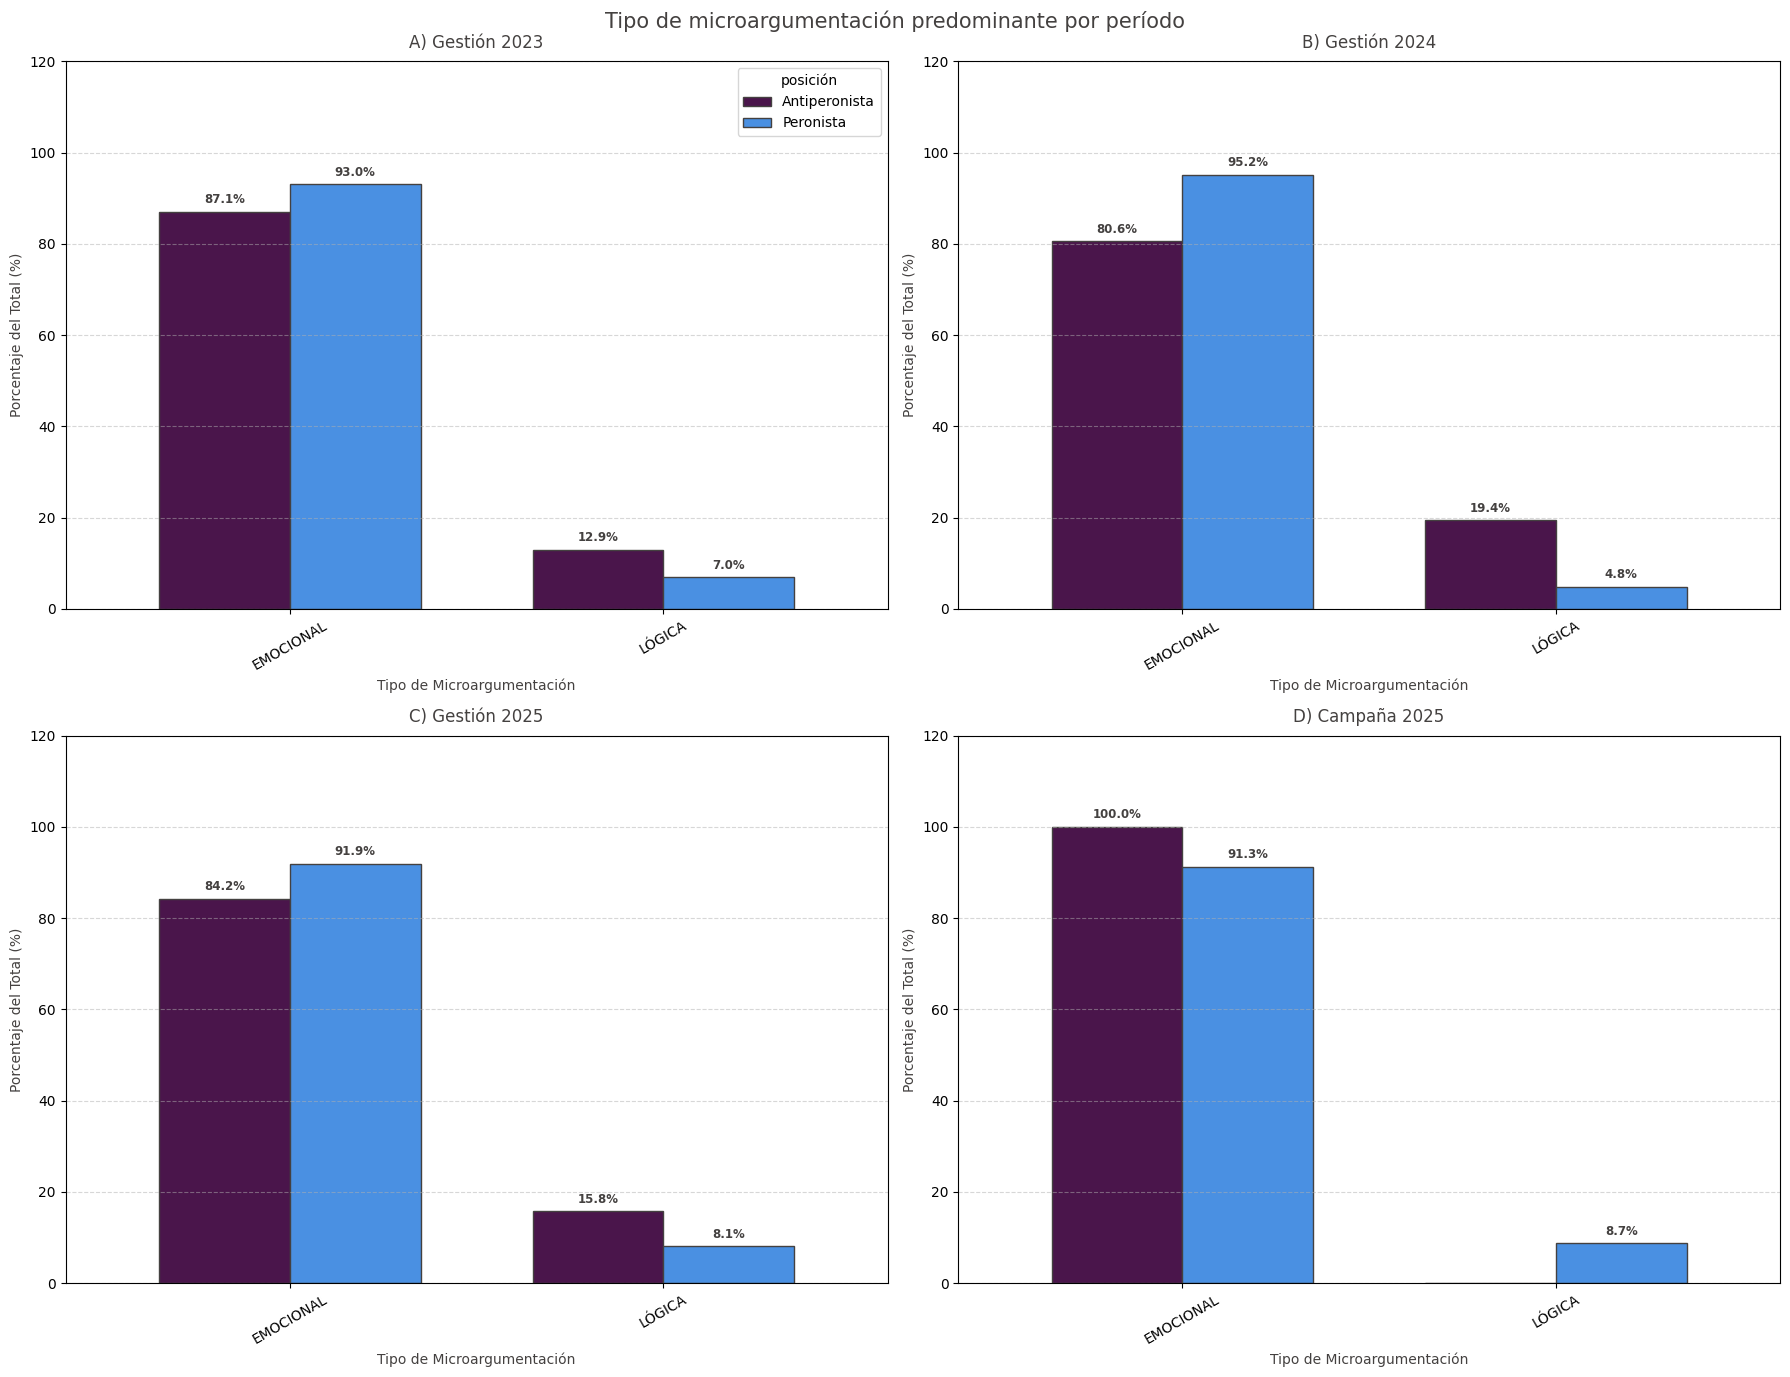

In [ ]:
# 1. Definimos los diccionarios o tuplas con los 4 DataFrames y sus respectivos títulos
# (Asegurate de que estas variables sean las que tenés cargadas en tu Colab:
# ej. df_gestion_2023, df_gestion_2024, df_gestion_2025, df_campana_2025)
datasets_analisis = [
    (df_campana_2023, 'A) Gestión 2023'),
    (df_gestion_2024, 'B) Gestión 2024'),
    (df_gestion_2025, 'C) Gestión 2025'),
    (df_campana_2025, 'D) Campaña 2025')
]

# 2. Configuración de la figura general con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# 3. Iteramos sobre cada DataFrame para construir su subplot correspondiente
for i, (df_sub, titulo_subplot) in enumerate(datasets_analisis):
    ax = axes_flat[i]

    if df_sub is not None and not df_sub.empty:
        # Copia y limpieza del df de la sección
        df_p = df_sub.copy()

        # Validamos que existan las columnas clave
        if 'tipo_de_microargumentación' in df_p.columns and 'posición' in df_p.columns:

            # Tabla cruzada para calcular porcentajes por posición
            tabla_arg = pd.crosstab(
                df_p['tipo_de_microargumentación'],
                df_p['posición'],
                normalize='columns'
            ) * 100

            if not tabla_arg.empty:
                # Graficamos las barras
                tabla_arg.plot(
                    kind='bar',
                    ax=ax,
                    color=colores_barras,
                    edgecolor='#444140',
                    linewidth=1,
                    legend=(i == 0), # Mostrar leyenda solo en el primer subplot para no saturar
                    width=0.7
                )

                ax.set_title(titulo_subplot, fontsize=12, pad=10, color='#444140')
                ax.set_xlabel('Tipo de Microargumentación', fontsize=10, color='#444140')
                ax.set_ylabel('Porcentaje del Total (%)', fontsize=10, color='#444140')

                # Límite Y extendido a 120 para que las etiquetas respiren
                ax.set_ylim(0, 120)
                ax.set_xlim(-0.6, len(tabla_arg) - 0.4)

                # --- Etiquetas de porcentaje con un decimal arriba de cada barra ---
                for container in ax.containers:
                    heights = [bar.get_height() for bar in container]
                    labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

                    ax.bar_label(
                        container,
                        labels=labels,
                        padding=4,
                        fontsize=8.5,
                        color='#444140',
                        fontweight='bold',
                        rotation=0
                    )
                # -----------------------------------------------------------------

                ax.tick_params(axis='x', rotation=30)
                ax.grid(axis='y', linestyle='--', alpha=0.5)
                continue

    # En caso de que algún DataFrame esté vacío o falte alguna columna
    ax.text(0.5, 0.5, f'Sin datos para {titulo_subplot}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo_subplot, fontsize=12, pad=10, color='#444140')

# Título general de la figura
fig.suptitle('Tipo de microargumentación predominante por período', fontsize=15, color='#444140', y=0.98)

plt.tight_layout()
plt.show()

## Emociones en total

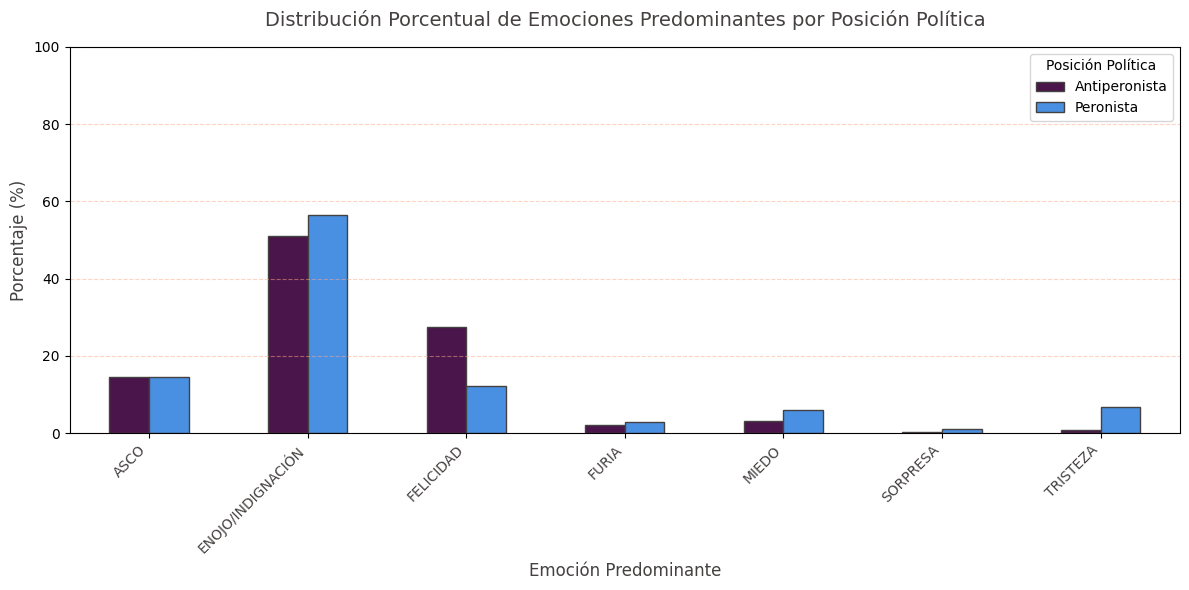

In [ ]:
# Copia de tu dataframe principal y unificación de Alegría/Felicidad
df_plot = df.copy()
if 'emoción_predominante' in df_plot.columns:
    df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
        'ALEGRÍA': 'FELICIDAD',
        'Alegría': 'FELICIDAD',
        'alegría': 'felicidad'
    })

# Tabla cruzada normalizada por filas (porcentaje respecto al total de cada posición política)
tabla_emociones_pct = pd.crosstab(
    df_plot['emoción_predominante'],
    df_plot['posición'],
    normalize='columns'
) * 100

# Definimos la lista de colores para las barras
colores_barras = ['#4a154b', '#4a90e2'] # Ajustá el orden si tus categorías de 'posición' difieren

ax = tabla_emociones_pct.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores_barras,
    edgecolor='#444140',
    linewidth=1,
    grid=False
)

plt.title('Distribución Porcentual de Emociones Predominantes por Posición Política', fontsize=14, color='#444140', pad=15)
plt.xlabel('Emoción Predominante', fontsize=12, color='#444140')
plt.ylabel('Porcentaje (%)', fontsize=12, color='#444140')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right', color='#444140')
plt.legend(title='Posición Política')
plt.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')
plt.tight_layout()
plt.show()

# **Campaña 2023**

In [ ]:
# 1. Veamos qué valores tiene exactamente la columna ahora mismo
col_objetivo = 'promoción/apoyo_o_detracción/ataque'
print("Valores únicos antes de limpiar:", df_campana_2023[col_objetivo].unique())

# 2. Limpieza robusta usando reemplazo basado en minúsculas y sin acentos de referencia
df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].astype(str).str.strip().str.lower()

# Forzamos los reemplazos principales
remplazos = {
    'promocion': 'promoción',
    'promoción/apoyo': 'promoción', # por si acaso agrupa todo ahí
    'detraccion': 'detracción',
    'ataque': 'detracción' # si querés unificar ataque con detracción, o dejalos como están
}
df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].replace(remplazos)

print("Valores únicos después de limpiar:", df_campana_2023[col_objetivo].unique())

Valores únicos antes de limpiar: ['DETRACCIÓN' 'PROMOCIÓN' 'PROMOCION']
Valores únicos después de limpiar: ['detracción' 'promoción']


/tmp/ipykernel_3688/2639581504.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].astype(str).str.strip().str.lower()
/tmp/ipykernel_3688/2639581504.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_campana_2023[col_objetivo] = df_campana_2023[col_objetivo].replace(remplazos)


## Emociones por endogrupo, referente propio, referente contrario y exogrupo (2023)

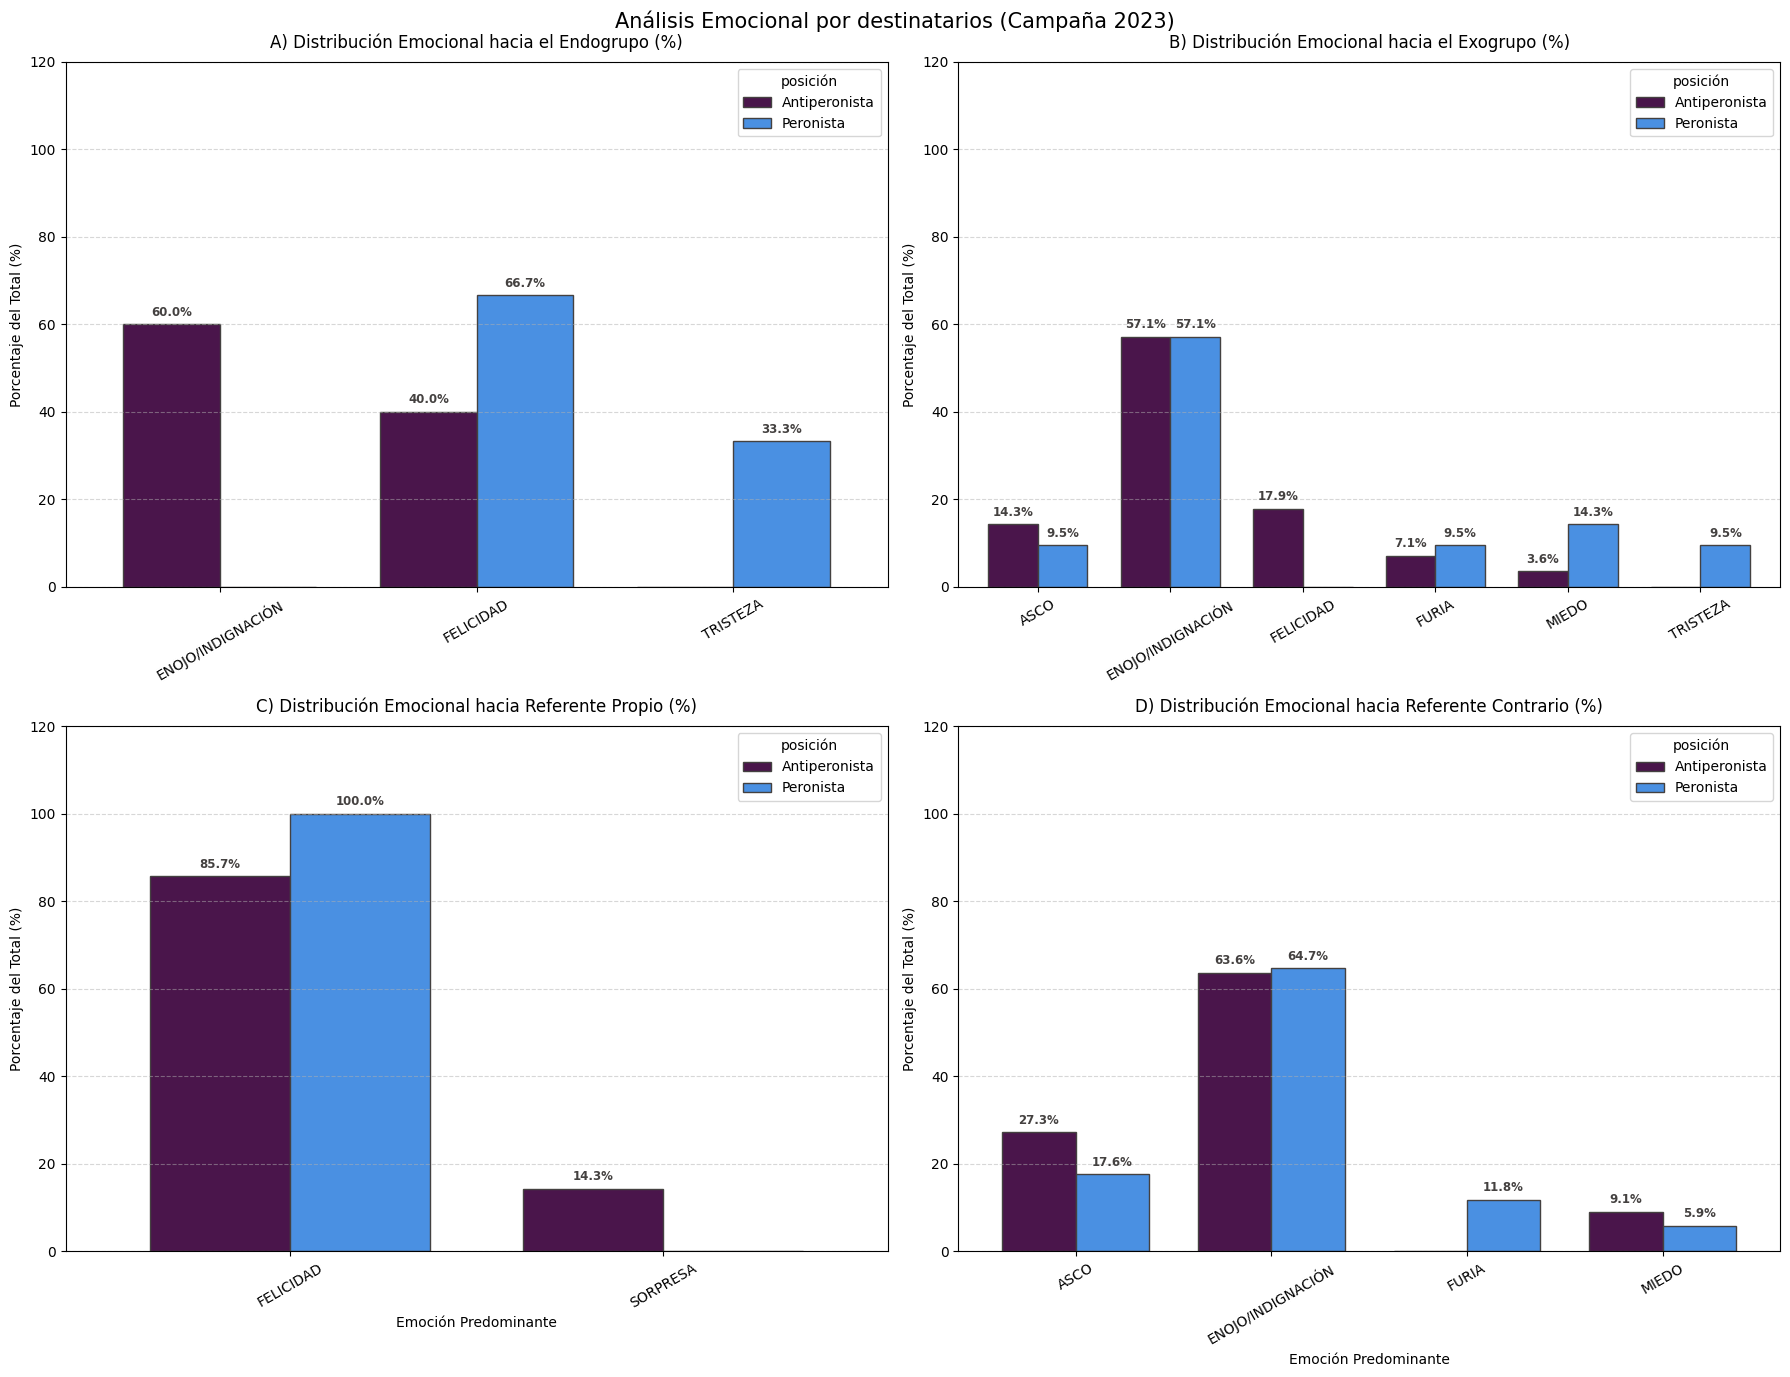

In [ ]:
# 1. Copia y preparación del DataFrame de Campaña 2023
df_plot = df_campana_2023.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna (cada combinación de destinatario y posición)
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2 (ampliamos el tamaño para que se vea imponente)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para encontrar la categoría exacta y graficar con etiquetas y límites limpios
def graficar_subplot_pct(ax, keyword, titulo, mostrar_xlabel=False):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col is not None:
        sub_df = tabla_porcentual[match_col]
        sub_df = sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías

        if not sub_df.empty:
            sub_df.plot(
                kind='bar',
                ax=ax,
                color=colores_barras,
                edgecolor='#444140',
                linewidth=1,
                legend=True,
                width=0.75 # Barras más anchas y proporcionadas
            )
            ax.set_title(titulo, fontsize=12, pad=10)
            ax.set_xlabel('Emoción Predominante' if mostrar_xlabel else '', fontsize=10)
            ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)

            # Límite Y extendido a 120 para que las etiquetas entren holgadas
            ax.set_ylim(0, 120)
            ax.set_xlim(-0.6, len(sub_df) - 0.4)

            # --- Agregar etiquetas de porcentaje arriba de cada barra ---
            for container in ax.containers:
                heights = [bar.get_height() for bar in container]
                labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

                ax.bar_label(
                    container,
                    labels=labels,
                    padding=4,      # Espaciado cómodo respecto a la barra
                    fontsize=8.5,   # Tamaño de fuente claro y legible
                    color='#444140',
                    fontweight='bold',
                    rotation=0
                )
            # -------------------------------------------------------------

            ax.tick_params(axis='x', rotation=30)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            return

    ax.text(0.5, 0.5, f'Sin datos de {keyword.capitalize()}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo, fontsize=12, pad=10)

# Aplicamos la función a cada cuadrante con su respectivo título para la Campaña 2023
graficar_subplot_pct(ax_endo, 'endogrupo', 'A) Distribución Emocional hacia el Endogrupo (%)', mostrar_xlabel=False)
graficar_subplot_pct(ax_exo, 'exogrupo', 'B) Distribución Emocional hacia el Exogrupo (%)', mostrar_xlabel=False)
graficar_subplot_pct(ax_propio, 'propio', 'C) Distribución Emocional hacia Referente Propio (%)', mostrar_xlabel=True)
graficar_subplot_pct(ax_contrario, 'contrario', 'D) Distribución Emocional hacia Referente Contrario (%)', mostrar_xlabel=True)

# Título general de la figura
fig.suptitle('Análisis Emocional por destinatarios (Campaña 2023)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Asegurémonos de estandarizar las columnas si es necesario (igual que hiciste con el 2025)
df_2023_plot = df_campana_2023.copy()
'destinatario_de_la_promoción/detracción' == 'destinatario_de_la_promoción/detracción' # Cambiala si se llama distinto en este df
df_2023_plot['destinatario_de_la_promoción/detracción'] = df_2023_plot['destinatario_de_la_promoción/detracción'].astype(str).str.strip()

# 2. Filtramos el caso de Endogrupo + Peronista + Enojo/Indignación
caso_2023 = df_2023_plot[
    (df_2023_plot['posición'].str.lower() == 'peronista') &
    (df_2023_plot['emoción_predominante'].str.upper().str.contains('ENOJO|INDIGNACIÓN')) &
    (df_2023_plot['destinatario_de_la_promoción/detracción'].str.lower().str.contains('endogrupo'))
]

print(f"Total de casos encontrados para 2023: {len(caso_2023)}")

# 3. Si hay varios, te muestra los primeros; si es uno solo, te muestra el texto directo
if len(caso_2023) > 0:
    'texto_del_posteo' == 'texto_del_posteo' # Reemplaza por 'tweet', 'content' o el nombre real de tu columna de texto

    for i, row in enumerate(caso_2023['texto_del_posteo'].head(5)):
        print(f"\n--- POSTEO 2023 #{i+1} ---")
        print(row)
else:
    print("Revisá si la posición se escribe exactamente 'peronista' o si la emoción tiene otra variante en 2023.")

Total de casos encontrados para 2023: 0
Revisá si la posición se escribe exactamente 'peronista' o si la emoción tiene otra variante en 2023.


# **Primer año de gestión presidencial (2024)**

## Emociones por endogrupo, referente propio, referente contrario y exogrupo (2024)

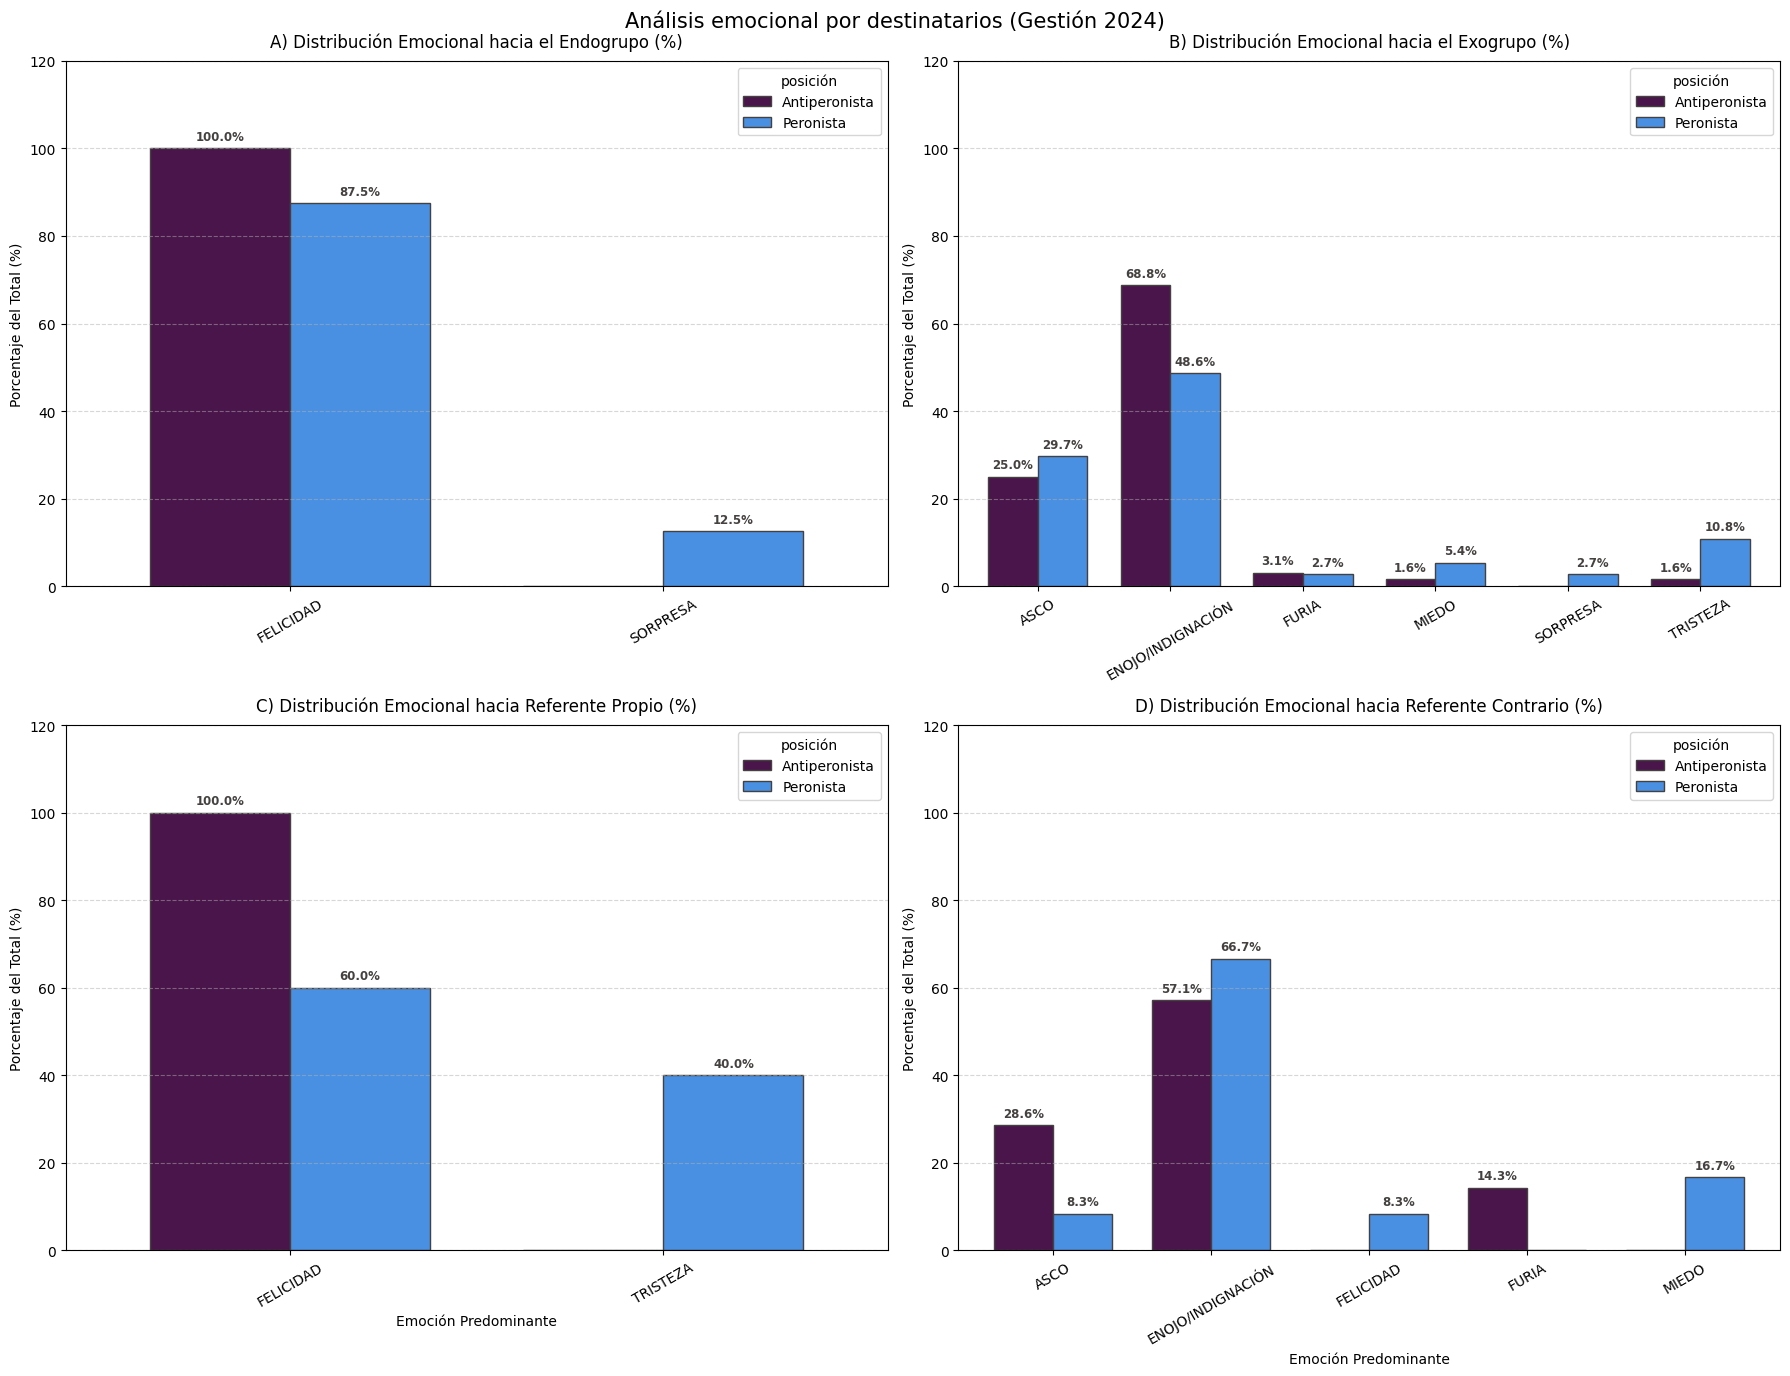

In [ ]:
# 1. Copia y preparación del DataFrame de Gestión 2024
df_plot = df_gestion_2024.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para encontrar la categoría exacta, graficar y etiquetar estéticamente
def graficar_subplot_pct(ax, keyword, titulo, mostrar_xlabel=False):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col is not None:
        sub_df = tabla_porcentual[match_col]
        sub_df = sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías

        if not sub_df.empty:
            sub_df.plot(
                kind='bar',
                ax=ax,
                color=colores_barras,
                edgecolor='#444140',
                linewidth=1,
                legend=True,
                width=0.75 # Aumentado de 0.4 a 0.75 para que las barras sean más anchas y claras
            )
            ax.set_title(titulo, fontsize=12, pad=10)
            ax.set_xlabel('Emoción Predominante' if mostrar_xlabel else '', fontsize=10)
            ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)

            # Límite Y extendido a 120 para dar espacio superior
            ax.set_ylim(0, 120)
            ax.set_xlim(-0.6, len(sub_df) - 0.4)

            # --- Etiquetas de porcentaje con mejor espaciado ---
            for container in ax.containers:
                heights = [bar.get_height() for bar in container]
                labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

                ax.bar_label(
                    container,
                    labels=labels,
                    padding=4,      # Un poco más de separación respecto a la barra
                    fontsize=8.5,   # Tamaño legible
                    color='#444140',
                    fontweight='bold',
                    rotation=0
                )
            # ---------------------------------------------------

            ax.tick_params(axis='x', rotation=30)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            return

    ax.text(0.5, 0.5, f'Sin datos de {keyword.capitalize()}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo, fontsize=12, pad=10)

# Aplicamos la función a cada cuadrante con su respectivo título para la Gestión 2024
graficar_subplot_pct(ax_endo, 'endogrupo', 'A) Distribución Emocional hacia el Endogrupo (%)', mostrar_xlabel=False)
graficar_subplot_pct(ax_exo, 'exogrupo', 'B) Distribución Emocional hacia el Exogrupo (%)', mostrar_xlabel=False)
graficar_subplot_pct(ax_propio, 'propio', 'C) Distribución Emocional hacia Referente Propio (%)', mostrar_xlabel=True)
graficar_subplot_pct(ax_contrario, 'contrario', 'D) Distribución Emocional hacia Referente Contrario (%)', mostrar_xlabel=True)

# Título general de la figura
fig.suptitle('Análisis emocional por destinatarios (Gestión 2024)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

In [ ]:
# Verificamos los valores reales actuales en el dataframe original recargado
print(df_gestion_2024.groupby(['posición', 'destinatario_de_la_promoción/detracción', 'emoción_predominante']).size())

posición       destinatario_de_la_promoción/detracción  emoción_predominante
Antiperonista  ENDOGRUPO                                FELICIDAD               13
               EXOGRUPO                                 ASCO                    16
                                                        ENOJO/INDIGNACIÓN       44
                                                        FURIA                    2
                                                        MIEDO                    1
                                                        TRISTEZA                 1
               REFERENTE CONTRARIO                      ASCO                     2
                                                        ENOJO/INDIGNACIÓN        4
                                                        FURIA                    1
               REFERENTE PROPIO                         FELICIDAD               19
Peronista      ENDOGRUPO                                FELICIDAD                7
          

In [ ]:
# Buscamos exactamente los 3 registros de Referente Propio + Felicidad del sector Peronista
df_busqueda = df_gestion_2024.copy()

# Limpiamos columnas para asegurar coincidencia exacta
df_busqueda['destinatario_limpio'] = df_busqueda['destinatario_de_la_promoción/detracción'].astype(str).str.strip().str.lower()
df_busqueda['posicion_limpia'] = df_busqueda['posición'].astype(str).str.strip().str.lower()
df_busqueda['emocion_limpia'] = df_busqueda['emoción_predominante'].astype(str).str.strip().str.upper()

resultados = df_busqueda[
    (df_busqueda['posicion_limpia'] == 'peronista') &
    (df_busqueda['destinatario_limpio'].str.contains('propio')) &
    (df_busqueda['emocion_limpia'] == 'FELICIDAD')
]

print(f"Total encontrados: {len(resultados)}")
display(resultados[['posición', 'destinatario_de_la_promoción/detracción', 'emoción_predominante', 'texto_del_posteo']])

Total encontrados: 3


,posición,destinatario_de_la_promoción/detracción,emoción_predominante,texto_del_posteo
109,Peronista,REFERENTE PROPIO,FELICIDAD,Agarró el país totalmente quebrado y no te hizo pasar hambre para salir adelante ✌🏼(Foto adjunta)
121,Peronista,REFERENTE PROPIO,FELICIDAD,"Si lo votamos, Milei ganó y no perdimos ningun derechos."
192,Peronista,REFERENTE PROPIO,FELICIDAD,"No amigos, no sale al balcón ""para jetonear"". Creó 17 universidades nacionales."


In [ ]:
# Copia y limpieza para la consulta
df_conteo = df_gestion_2024.copy()
df_conteo['destinatario_limpio'] = df_conteo['destinatario_de_la_promoción/detracción'].astype(str).str.strip().str.lower()
df_conteo['posicion_limpia'] = df_conteo['posición'].astype(str).str.strip().str.lower()

# Filtramos por sector peronista y que mencione 'contrario' o contenga errores tipográficos similares
contrarios_peronistas = df_conteo[
    (df_conteo['posicion_limpia'] == 'peronista') &
    (df_conteo['destinatario_limpio'].str.contains('contrario|cotnrario'))
]

print(f"Total de registros hacia el referente contrario (Peronista): {len(contrarios_peronistas)}")

# Si querés ver el desglose por cómo está escrito exactamente en el campo:
print("\nDesglose por valor exacto:")
print(contrarios_peronistas['destinatario_de_la_promoción/detracción'].value_counts())

Total de registros hacia el referente contrario (Peronista): 12

Desglose por valor exacto:
destinatario_de_la_promoción/detracción
REFERENTE CONTRARIO    12
Name: count, dtype: int64


In [ ]:
# Buscamos las filas donde el destinatario contenga errores o variaciones de 'cotnrario' o 'contrario'
filas_encontradas = df_gestion_2024[
    df_gestion_2024['destinatario_de_la_promoción/detracción']
    .astype(str)
    .str.contains('cotnrario|contrario', case=False, na=False)
]

# Mostramos los índices (posiciones de fila) y los datos clave
print("Índices de las filas encontradas:")
print(filas_encontradas.index.tolist())

# Mostramos un resumen con la posición, el destinatario exacto y la emoción
display(filas_encontradas[['posición', 'destinatario_de_la_promoción/detracción', 'emoción_predominante']])

Índices de las filas encontradas:
[118, 132, 134, 137, 139, 148, 157, 158, 166, 193, 197, 212, 226, 242, 247, 248, 256, 262, 266]


,posición,destinatario_de_la_promoción/detracción,emoción_predominante
118,Antiperonista,REFERENTE CONTRARIO,ASCO
132,Peronista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
134,Peronista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
137,Antiperonista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
139,Antiperonista,REFERENTE CONTRARIO,FURIA
148,Antiperonista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
157,Peronista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
158,Peronista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
166,Peronista,REFERENTE CONTRARIO,ENOJO/INDIGNACIÓN
193,Peronista,REFERENTE CONTRARIO,ASCO


# **Gestion 2025**

## Emociones por endogrupo, referente propio, referente contrario y exogrupo durante la gestión 2025

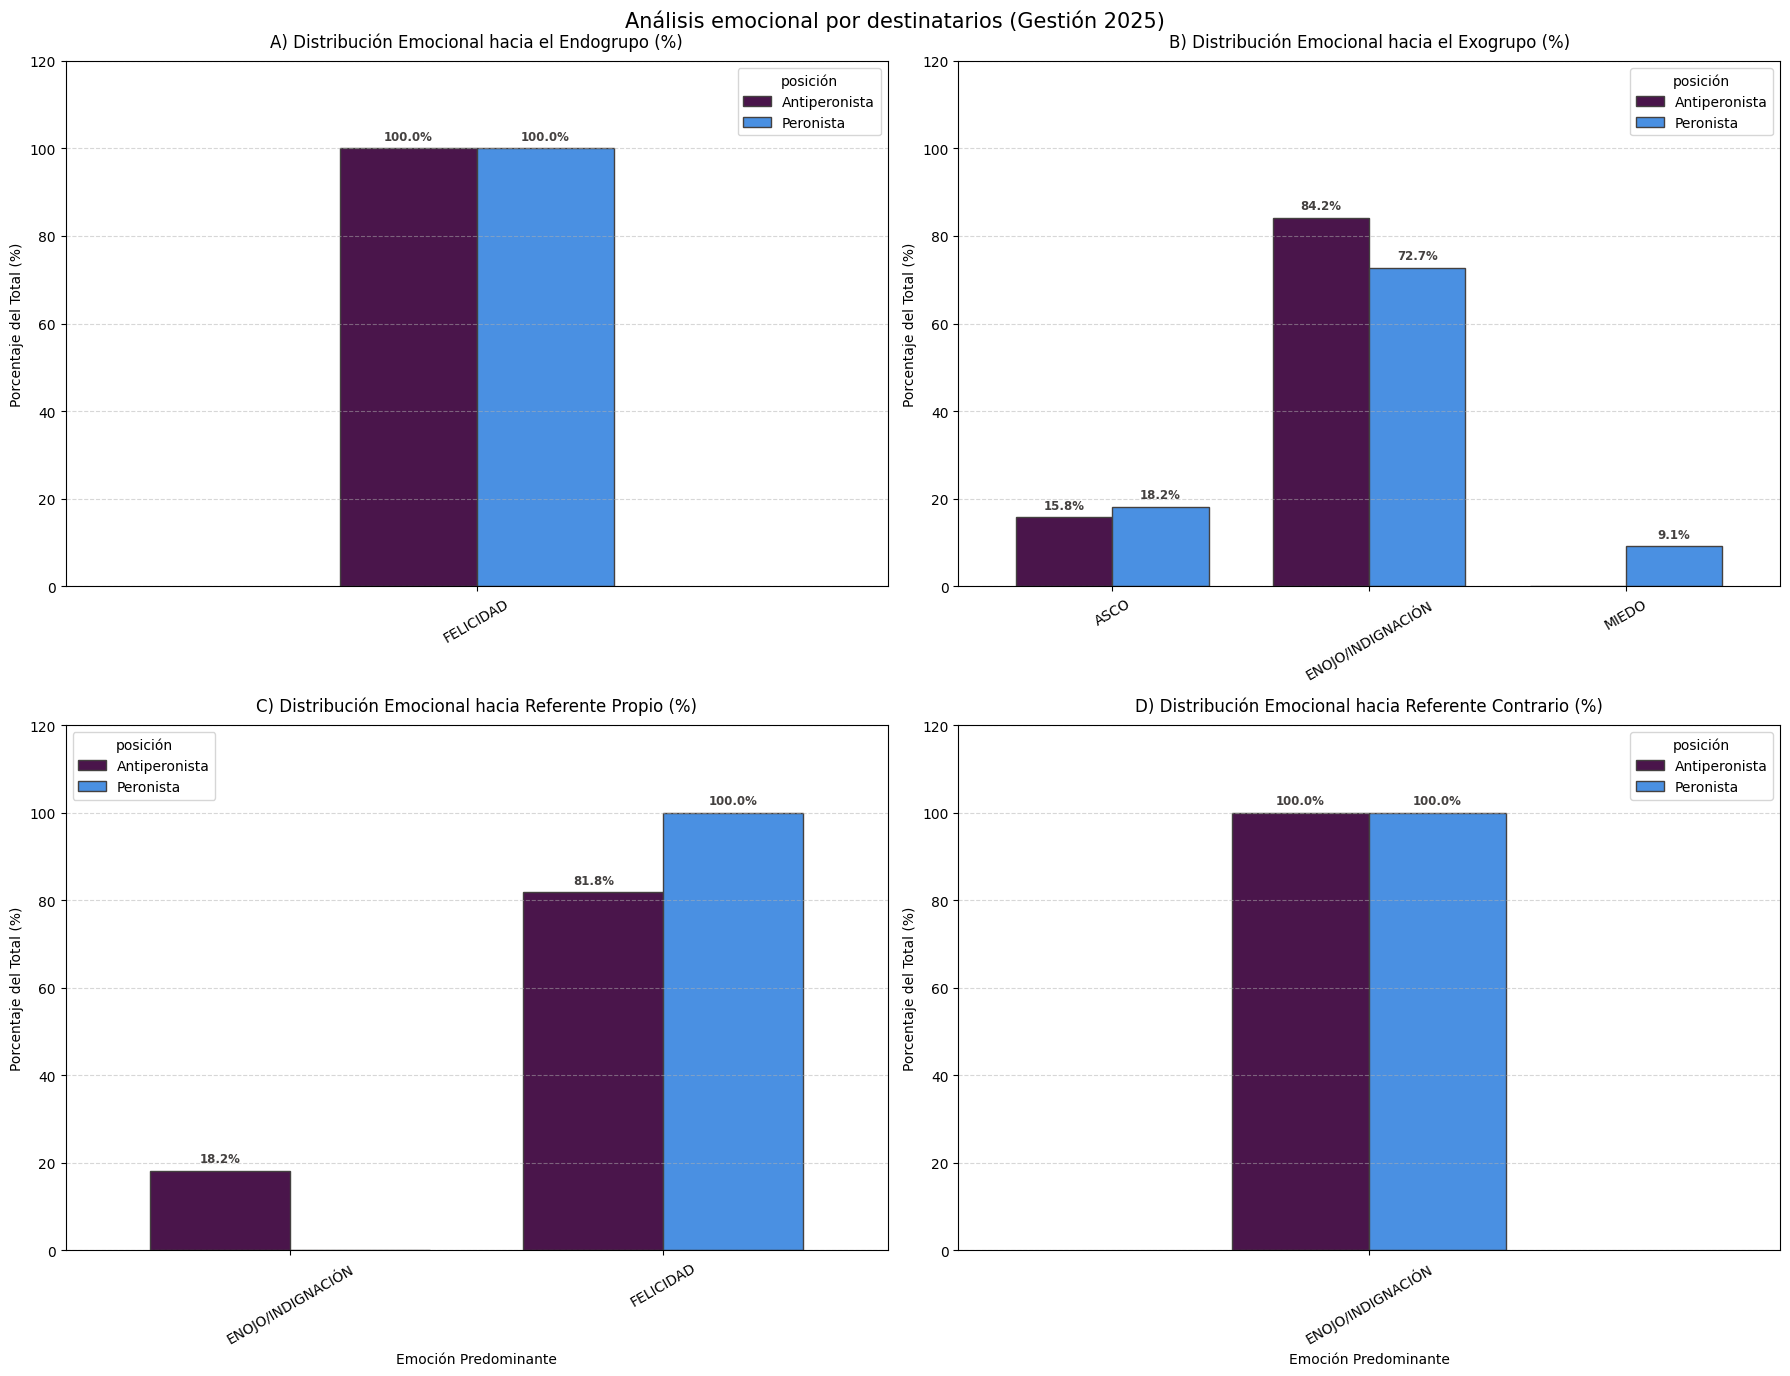

In [ ]:
# 1. Copia y preparación del DataFrame
df_plot = df_gestion_2025.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar que ahora acepta un parámetro 'ancho_barra' personalizado
def graficar_subplot(ax, keyword, titulo, mostrar_xlabel=False, ancho_barra=0.75):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col is not None:
        sub_df = tabla_porcentual[match_col]
        sub_df = sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías

        if not sub_df.empty:
            sub_df.plot(
                kind='bar',
                ax=ax,
                color=colores_barras,
                edgecolor='#444140',
                linewidth=1,
                legend=True,
                width=ancho_barra # Ancho dinámico según lo que le pasemos
            )
            ax.set_title(titulo, fontsize=12, pad=10)
            ax.set_xlabel('Emoción Predominante' if mostrar_xlabel else '', fontsize=10)
            ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)

            # Extendemos el límite Y a 120 para dar espacio a las etiquetas
            ax.set_ylim(0, 120)
            ax.set_xlim(-0.6, len(sub_df) - 0.4)

            # --- Agregar etiquetas de porcentaje arriba de cada barra ---
            for container in ax.containers:
                heights = [bar.get_height() for bar in container]
                labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

                ax.bar_label(
                    container,
                    labels=labels,
                    padding=4,
                    fontsize=8.5,
                    color='#444140',
                    fontweight='bold',
                    rotation=0
                )
            # -------------------------------------------------------------

            ax.tick_params(axis='x', rotation=30)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            return

    ax.text(0.5, 0.5, f'Sin datos de {keyword.capitalize()}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo, fontsize=12, pad=10)

# Aplicamos los grosores personalizados: ancho 0.4 para A y D, y 0.75 para B y C
graficar_subplot(ax_endo, 'endogrupo', 'A) Distribución Emocional hacia el Endogrupo (%)', mostrar_xlabel=False, ancho_barra=0.4)
graficar_subplot(ax_exo, 'exogrupo', 'B) Distribución Emocional hacia el Exogrupo (%)', mostrar_xlabel=False, ancho_barra=0.75)
graficar_subplot(ax_propio, 'propio', 'C) Distribución Emocional hacia Referente Propio (%)', mostrar_xlabel=True, ancho_barra=0.75)
graficar_subplot(ax_contrario, 'contrario', 'D) Distribución Emocional hacia Referente Contrario (%)', mostrar_xlabel=True, ancho_barra=0.4)

# Título general de la figura
fig.suptitle('Análisis emocional por destinatarios (Gestión 2025)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

# **Campaña legsilativa 2025**

## Emociones por endogrupo, referente propio, referente contrario y exogrupo durante la campaña 2025

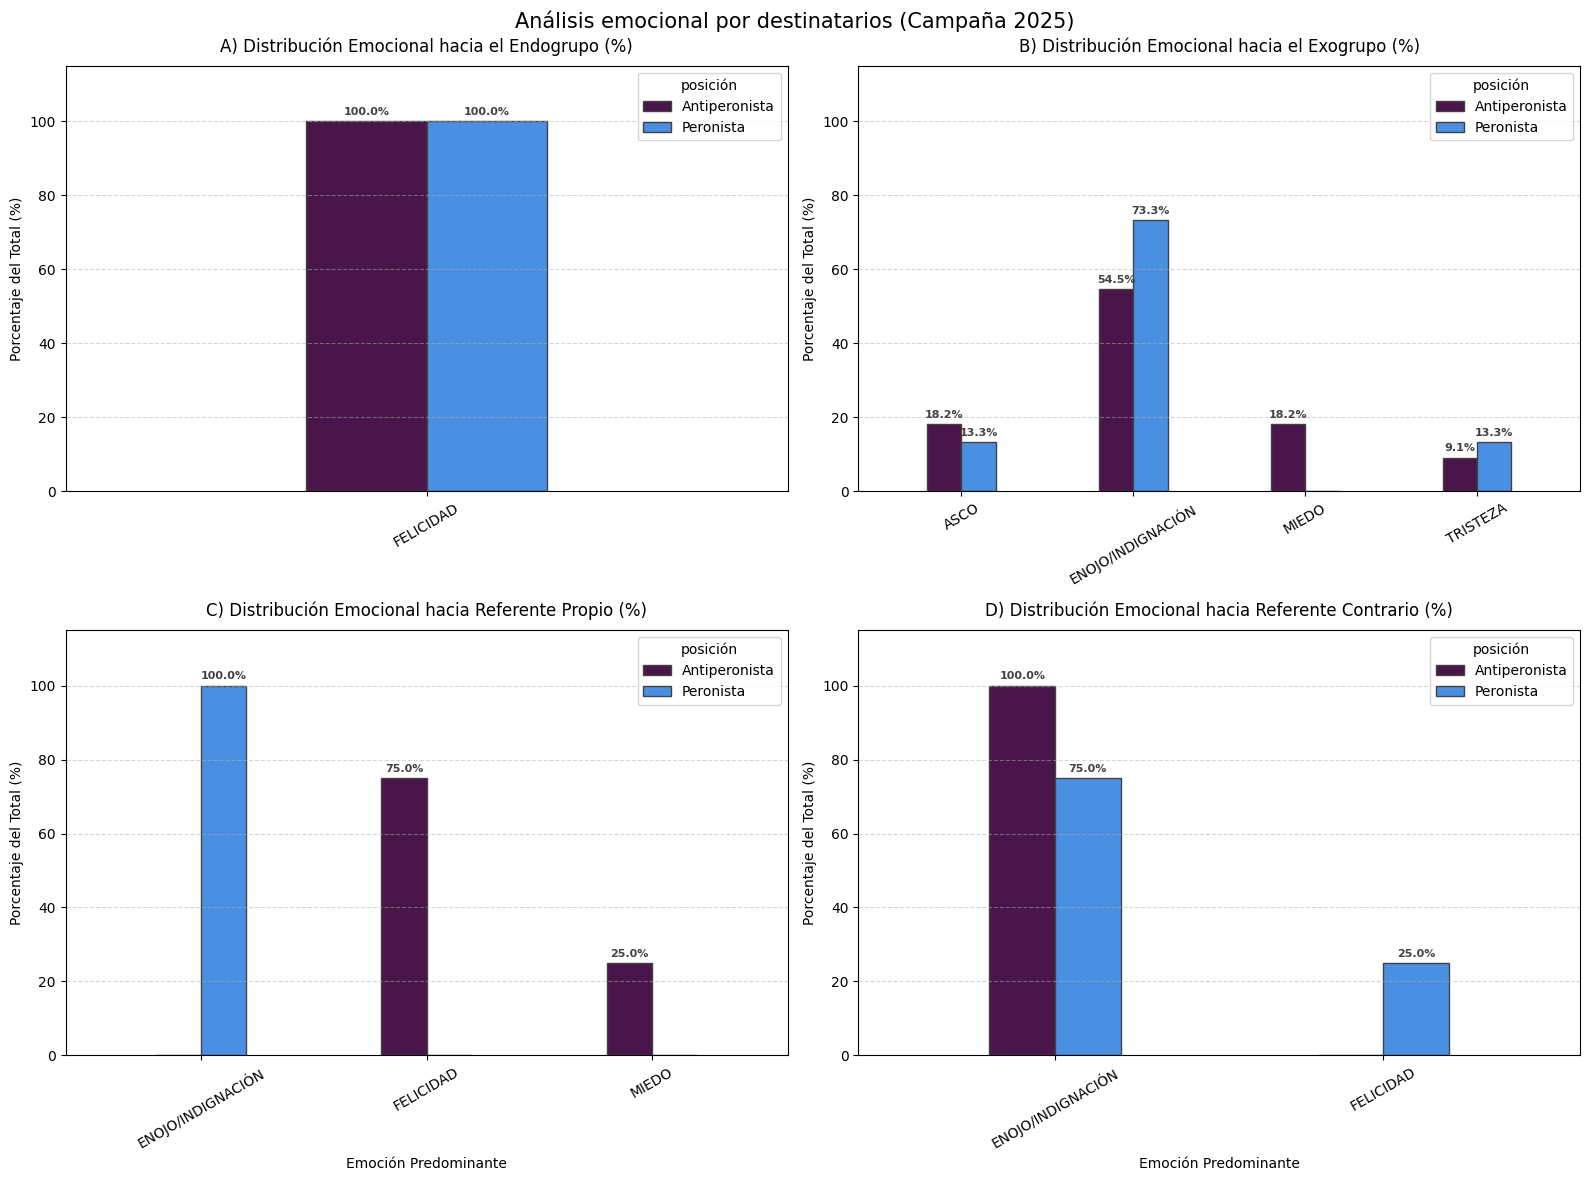

In [ ]:
# 1. Copia y preparación del DataFrame para Campaña 2025
df_plot = df_campana_2025.copy()

# Unificamos variantes de alegría en felicidad
df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
    'ALEGRÍA': 'FELICIDAD',
    'Alegría': 'FELICIDAD',
    'alegría': 'felicidad'
})

columna_destinatario = 'destinatario_de_la_promoción/detracción'
df_plot[columna_destinatario] = df_plot[columna_destinatario].astype(str).str.strip()

# 2. Creamos la tabla cruzada general desglosando por Emoción, Destinatario y Posición
tabla_emociones_destinatario = pd.pivot_table(
    df_plot,
    index='emoción_predominante',
    columns=[columna_destinatario, 'posición'],
    aggfunc='size',
    fill_value=0
)

# Convertimos los valores absolutos a porcentajes por cada columna
tabla_porcentual = tabla_emociones_destinatario.div(tabla_emociones_destinatario.sum(axis=0), axis=1) * 100

# 3. Configuración de la figura con 4 subplots en formato 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ax_endo, ax_exo = axes[0, 0], axes[0, 1]
ax_propio, ax_contrario = axes[1, 0], axes[1, 1]

colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

# Función auxiliar para obtener, graficar y etiquetar estéticamente cada subplot
def graficar_subplot(ax, keyword, titulo, mostrar_xlabel=False):
    match_col = next((col for col in tabla_porcentual.columns.levels[0] if keyword.lower() in str(col).lower()), None)
    if match_col is not None:
        sub_df = tabla_porcentual[match_col]
        sub_df = sub_df[sub_df.sum(axis=1) > 0] # Filtramos filas vacías

        if not sub_df.empty:
            # Usamos width y position explícitos para controlar el ancho de las barras
            sub_df.plot(
                kind='bar',
                ax=ax,
                color=colores_barras,
                edgecolor='#444140',
                linewidth=1,
                legend=True,
                width=0.4 # Controla la delgadez de las barras
            )
            ax.set_title(titulo, fontsize=12, pad=10)
            ax.set_xlabel('Emoción Predominante' if mostrar_xlabel else '', fontsize=10)
            ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)

            # Extendemos el límite Y a 115 para dar espacio a las etiquetas superiores
            ax.set_ylim(0, 115)

            # Control de márgenes laterales en el eje X para que las barras no toquen los bordes
            ax.set_xlim(-0.6, len(sub_df) - 0.4)

            # --- Agregar etiquetas de porcentaje arriba de cada barra ---
            for container in ax.containers:
                heights = [bar.get_height() for bar in container]
                labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

                ax.bar_label(
                    container,
                    labels=labels,
                    padding=3,
                    fontsize=8,
                    color='#444140',
                    fontweight='bold',
                    rotation=0
                )
            # -------------------------------------------------------------

            ax.tick_params(axis='x', rotation=30)
            ax.grid(axis='y', linestyle='--', alpha=0.5)
            return

    ax.text(0.5, 0.5, f'Sin datos de {keyword.capitalize()}', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo, fontsize=12, pad=10)

# Aplicamos la función a cada cuadrante con su respectivo título para la Campaña 2025
graficar_subplot(ax_endo, 'endogrupo', 'A) Distribución Emocional hacia el Endogrupo (%)', mostrar_xlabel=False)
graficar_subplot(ax_exo, 'exogrupo', 'B) Distribución Emocional hacia el Exogrupo (%)', mostrar_xlabel=False)
graficar_subplot(ax_propio, 'propio', 'C) Distribución Emocional hacia Referente Propio (%)', mostrar_xlabel=True)
graficar_subplot(ax_contrario, 'contrario', 'D) Distribución Emocional hacia Referente Contrario (%)', mostrar_xlabel=True)

# Título general de la figura
fig.suptitle('Análisis emocional por destinatarios (Campaña 2025)', fontsize=15, y=0.98)

plt.tight_layout()
plt.show()

In [ ]:
# Filtramos los textos que coinciden con esa condición para leerlos
textos_raros = df_plot[
    (df_plot[columna_destinatario].str.contains('endogrupo', case=False, na=False)) &
    (df_plot['posición'] == 'peronista') &
    (df_plot['emoción_predominante'] == 'ASCO') # o 'asco' según cómo esté escrito
]

# Mostramos algunos ejemplos de los textos y su etiqueta
print(f"Total de casos: {len(textos_raros)}")
display(textos_raros[['texto_del_posteo', 'emoción_predominante', 'destinatario_de_la_promoción/detracción', 'posición']].head(10))

Total de casos: 0


,texto_del_posteo,emoción_predominante,destinatario_de_la_promoción/detracción,posición


In [ ]:
# 1. Buscamos el nombre exacto de la columna en el MultiIndex de Pandas
match_col = None
for col in tabla_porcentual.columns:
    # col es una tupla: (destinatario, posición)
    if 'endogrupo' in str(col[0]).lower():
        match_col = col[0]
        break

print(f"El destinatario exacto detectado es: {match_col}")

# 2. Filtramos el DataFrame original usando ese valor exacto
textos_exactos = df_plot[
    (df_plot[columna_destinatario] == match_col) &
    (df_plot['posición'].str.lower() == 'peronista') &
    (df_plot['emoción_predominante'].str.upper() == 'ASCO')
]

print(f"Total de casos reales: {len(textos_exactos)}")

# Si tienes una columna de texto (cambia 'texto' por el nombre real si se llama diferente, ej. 'content' o 'tweet')
# display(textos_exactos[['texto', 'emoción_predominante', columna_destinatario, 'posición']].head(10))

El destinatario exacto detectado es: ENDOGRUPO
Total de casos reales: 0


In [ ]:
# 1. Imprimamos la tabla porcentual completa para el endogrupo
print("--- TABLA PORCENTUAL PARA ENDOGRUPO ---")
match_cols = [col for col in tabla_porcentual.columns if 'endogrupo' in str(col[0]).lower()]
display(tabla_porcentual[match_cols])

# 2. Vamos a buscar específicamente en el DataFrame original qué filas dieron 'ASCO'
# usando los valores únicos reales de la columna de emociones para evitar errores de tipeo
print("\n--- EMOCIONES EN EL DF_PLOT ---")
print(df_plot['emoción_predominante'].unique())

# 3. Filtro directo por posición y emoción (sin filtrar por texto de destinatario todavía para ver qué sale)
fuego_amigo = df_plot[
    (df_plot['posición'].str.lower() == 'peronista') &
    (df_plot['emoción_predominante'].str.upper().str.contains('ASCO', na=False))
]

print(f"\nTotal de casos peronistas con emoción de asco en todo el dataset: {len(fuego_amigo)}")
if len(fuego_amigo) > 0:
    print("Destinatarios de esos casos:")
    print(fuego_amigo[columna_destinatario].value_counts())

--- TABLA PORCENTUAL PARA ENDOGRUPO ---


destinatario_de_la_promoción/detracción     ENDOGRUPO          
posición                                Antiperonista Peronista
emoción_predominante                                           
ASCO                                              0.0       0.0
ENOJO/INDIGNACIÓN                                 0.0       0.0
FELICIDAD                                       100.0     100.0
MIEDO                                             0.0       0.0
TRISTEZA                                          0.0       0.0


--- EMOCIONES EN EL DF_PLOT ---
['ENOJO/INDIGNACIÓN' 'MIEDO' 'FELICIDAD' 'ASCO' 'TRISTEZA']

Total de casos peronistas con emoción de asco en todo el dataset: 3
Destinatarios de esos casos:
destinatario_de_la_promoción/detracción
EXOGRUPO    2
w           1
Name: count, dtype: int64


In [ ]:
# Ver los valores absolutos (conteo real) de esa intersección en la tabla dinámica
display(tabla_emociones_destinatario)

destinatario_de_la_promoción/detracción     ENDOGRUPO                EXOGRUPO  \
posición                                Antiperonista Peronista Antiperonista   
emoción_predominante                                                            
ASCO                                                0         0             2   
ENOJO/INDIGNACIÓN                                   0         0             6   
FELICIDAD                                           3         2             0   
MIEDO                                               0         0             2   
TRISTEZA                                            0         0             1   

destinatario_de_la_promoción/detracción           REFERENTE CONTRARIO  \
posición                                Peronista       Antiperonista   
emoción_predominante                                                    
ASCO                                            2                   0   
ENOJO/INDIGNACIÓN                              11                   4   
FELICIDAD                                       0                   0   
MIEDO                                           0                   0   
TRISTEZA                                        2                   0   

destinatario_de_la_promoción/detracción           REFERENTE PROPIO            \
posición                                Peronista    Antiperonista Peronista   
emoción_predominante                                                           
ASCO                                            0                0         0   
ENOJO/INDIGNACIÓN                               3                0         1   
FELICIDAD                                       1                3         0   
MIEDO                                           0                1         0   
TRISTEZA                                        0                0         0   

destinatario_de_la_promoción/detracción         w  
posición                                Peronista  
emoción_predominante                               
ASCO                                            1  
ENOJO/INDIGNACIÓN                               0  
FELICIDAD                                       0  
MIEDO                                           0  
TRISTEZA                                        0

In [ ]:
# Filtramos el DataFrame para aislar ese único caso
caso_unico = df_plot[
    (df_plot['posición'].str.lower() == 'peronista') &
    (df_plot['emoción_predominante'].str.upper() == 'ASCO') &
    (df_plot['destinatario_de_la_promoción/detracción'].str.lower().str.contains('endogrupo'))
]

# Mostramos el resultado (asegúrate de cambiar 'texto' por el nombre real de tu columna de texto si es diferente)
print(f"Casos encontrados: {len(caso_unico)}")

if len(caso_unico) > 0:
    # Si tu columna de texto se llama distinto, reemplaza 'texto' aquí abajo:
    columna_texto = 'texto' # Cambia esto si tu columna se llama 'content', 'tweet', 'mensaje', etc.

    print("\n--- CONTENIDO DEL POSTEO ---")
    print(caso_unico['texto_del_posteo'].values[0])

    print("\n--- METADATOS DEL CASO ---")
    display(caso_unico[['posición', 'destinatario_de_la_promoción/detracción', 'emoción_predominante']])

Casos encontrados: 0


# Evolución emociones

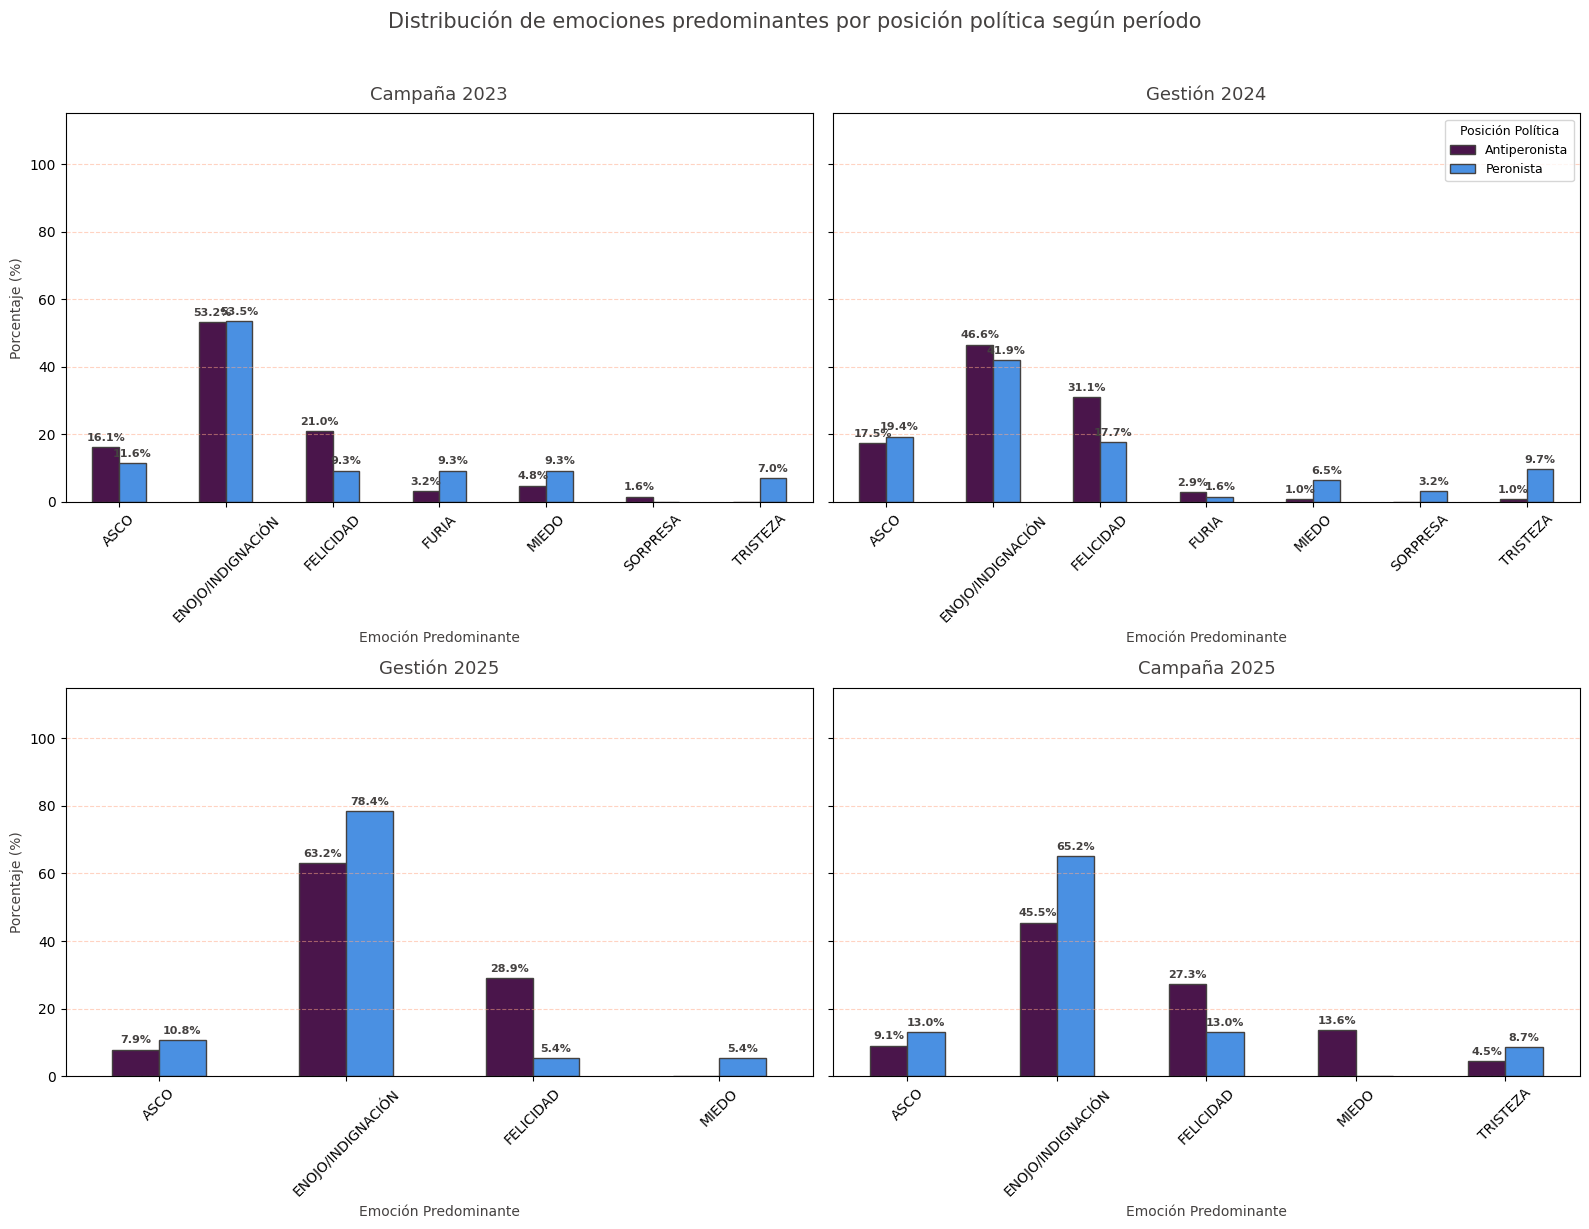

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, 'Campaña 2023'),
    (df_gestion_2024, 'Gestión 2024'),
    (df_gestion_2025, 'Gestión 2025'),
    (df_campana_2025, 'Campaña 2025')
]

# Creamos una figura con una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten() # Aplanamos para recorrerlos fácilmente con un bucle

colores_barras = ['#4a154b', '#4a90e2'] # antiperonista / peronista

for i, (df_actual, titulo_periodo) in enumerate(periodos):
    ax = axes[i]

    # Copia y unificación de Alegría en Felicidad
    df_plot = df_actual.copy()
    if 'emoción_predominante' in df_plot.columns:
        df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
            'ALEGRÍA': 'FELICIDAD',
            'Alegría': 'FELICIDAD',
            'alegría': 'felicidad'
        })

    # Tabla cruzada normalizada en porcentaje por posición política
    tabla_emociones = pd.crosstab(
        df_plot['emoción_predominante'],
        df_plot['posición'],
        normalize='columns'
    ) * 100

    # Graficar en el subplot correspondiente
    tabla_emociones.plot(
        kind='bar',
        ax=ax,
        color=colores_barras,
        edgecolor='#444140',
        linewidth=1,
        legend=(i == 1) # Mostramos la leyenda solo en un subplot para que no se sature
    )

    # --- NUEVO: Agregar etiquetas de porcentaje arriba de cada barra en cada subplot ---
    for container in ax.containers:
        heights = [bar.get_height() for bar in container]
        labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=8,
            color='#444140',
            fontweight='bold',
            rotation=0
        )
    # -------------------------------------------------------------------------------

    ax.set_title(f'{titulo_periodo}', fontsize=13, color='#444140', pad=10)
    ax.set_xlabel('Emoción Predominante', fontsize=10, color='#444140')
    ax.set_ylabel('Porcentaje (%)', fontsize=10, color='#444140')

    # Extendemos el límite Y a 115 para que las etiquetas superiores no se corten
    ax.set_ylim(0, 115)

    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')

    # Ajuste de leyenda si se muestra
    if i == 1:
        ax.legend(title='Posición Política', fontsize=9, title_fontsize=9, loc='upper right')

# Título general de la figura
fig.suptitle('Distribución de emociones predominantes por posición política según período', fontsize=15, color='#444140', y=1.02)

plt.tight_layout()
plt.show()

# Evolución detracción y promoción

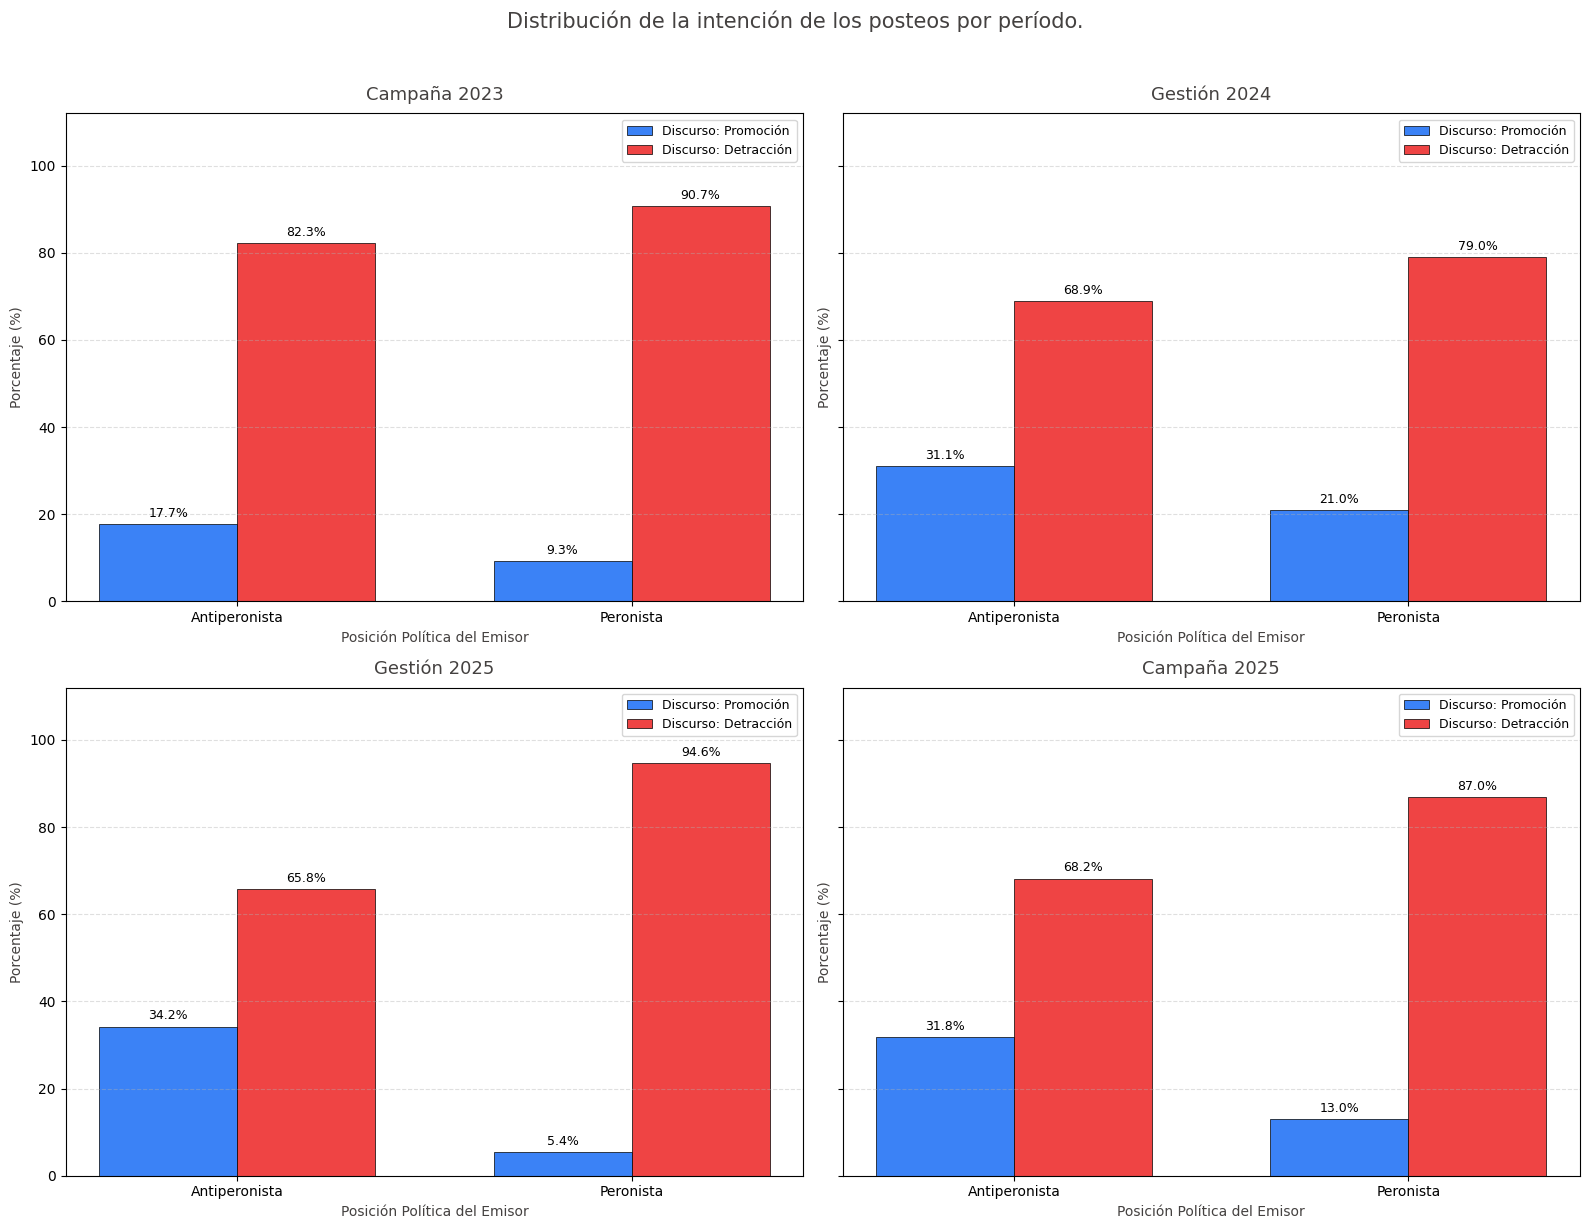

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, "Campaña 2023"),
    (df_gestion_2024, "Gestión 2024"),
    (df_gestion_2025, "Gestión 2025"),
    (df_campana_2025, "Campaña 2025"),
]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Aplanamos para recorrerlos fácilmente con un bucle

colores_discurso = {
    "promoción": "#3b82f6",  # Azul
    "detracción": "#ef4444",  # Rojo
}
categorias_fijas = ["promoción", "detracción"]

for i, (df_actual, titulo_periodo) in enumerate(periodos):
  ax = axes[i]

  # 1. Copia y preparación del DataFrame limpio para el período actual
  df_plot = df_actual.reset_index().copy()

  columna_objetivo = "promoción/apoyo_o_detracción/ataque"
  df_plot[columna_objetivo] = (
      df_plot[columna_objetivo]
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({"promocion": "promoción", "detraccion": "detracción"})
  )

  # 2. Creamos la tabla cruzada y aseguramos las categorías fijas
  tabla_general = pd.crosstab(df_plot["posición"], df_plot[columna_objetivo])

  for cat in categorias_fijas:
    if cat not in tabla_general.columns:
      tabla_general[cat] = 0
  tabla_general = tabla_general[categorias_fijas]

  # Calculamos la tabla porcentual por fila
  tabla_porcentual = tabla_general.div(tabla_general.sum(axis=1), axis=0) * 100

  posiciones = tabla_general.index
  x = np.arange(len(posiciones))
  ancho_barra = 0.35

  # 3. Gráfico de barras porcentuales para este subplot
  for j, tipo in enumerate(categorias_fijas):
    valores = tabla_porcentual[tipo].values
    offset = (j - 0.5) * ancho_barra

    barras = ax.bar(
        x + offset,
        valores,
        width=ancho_barra,
        label=f"Discurso: {tipo.capitalize()}",
        color=colores_discurso[tipo],
        edgecolor="black",
        linewidth=0.5,
    )
    # Agregamos las etiquetas con porcentaje, manejando posibles NaN si algún grupo está vacío
    ax.bar_label(
        barras,
        labels=[f"{v:.1f}%" if not np.isnan(v) else "0.0%" for v in valores],
        padding=3,
        fontsize=9,
    )

  ax.set_title(f"{titulo_periodo}", fontsize=13, pad=10, color="#444140")
  ax.set_xlabel("Posición Política del Emisor", fontsize=10, color="#444140")
  ax.set_ylabel("Porcentaje (%)", fontsize=10, color="#444140")
  ax.set_ylim(
      0, 112
  )  # Margen superior para que las etiquetas de porcentaje no queden cortadas
  ax.set_xticks(x)
  ax.set_xticklabels(posiciones, rotation=0, fontsize=10)
  ax.legend(fontsize=9, loc="upper right")
  ax.grid(True, linestyle="--", alpha=0.4, axis="y")

# Título general de la figura
fig.suptitle(
    "Distribución de la intención de los posteos por período.",
    fontsize=15,
    color="#444140",
    y=1.02,
)

plt.tight_layout()
plt.show()

# Evolución de la frecuencia por destinatario en los 4 bloques

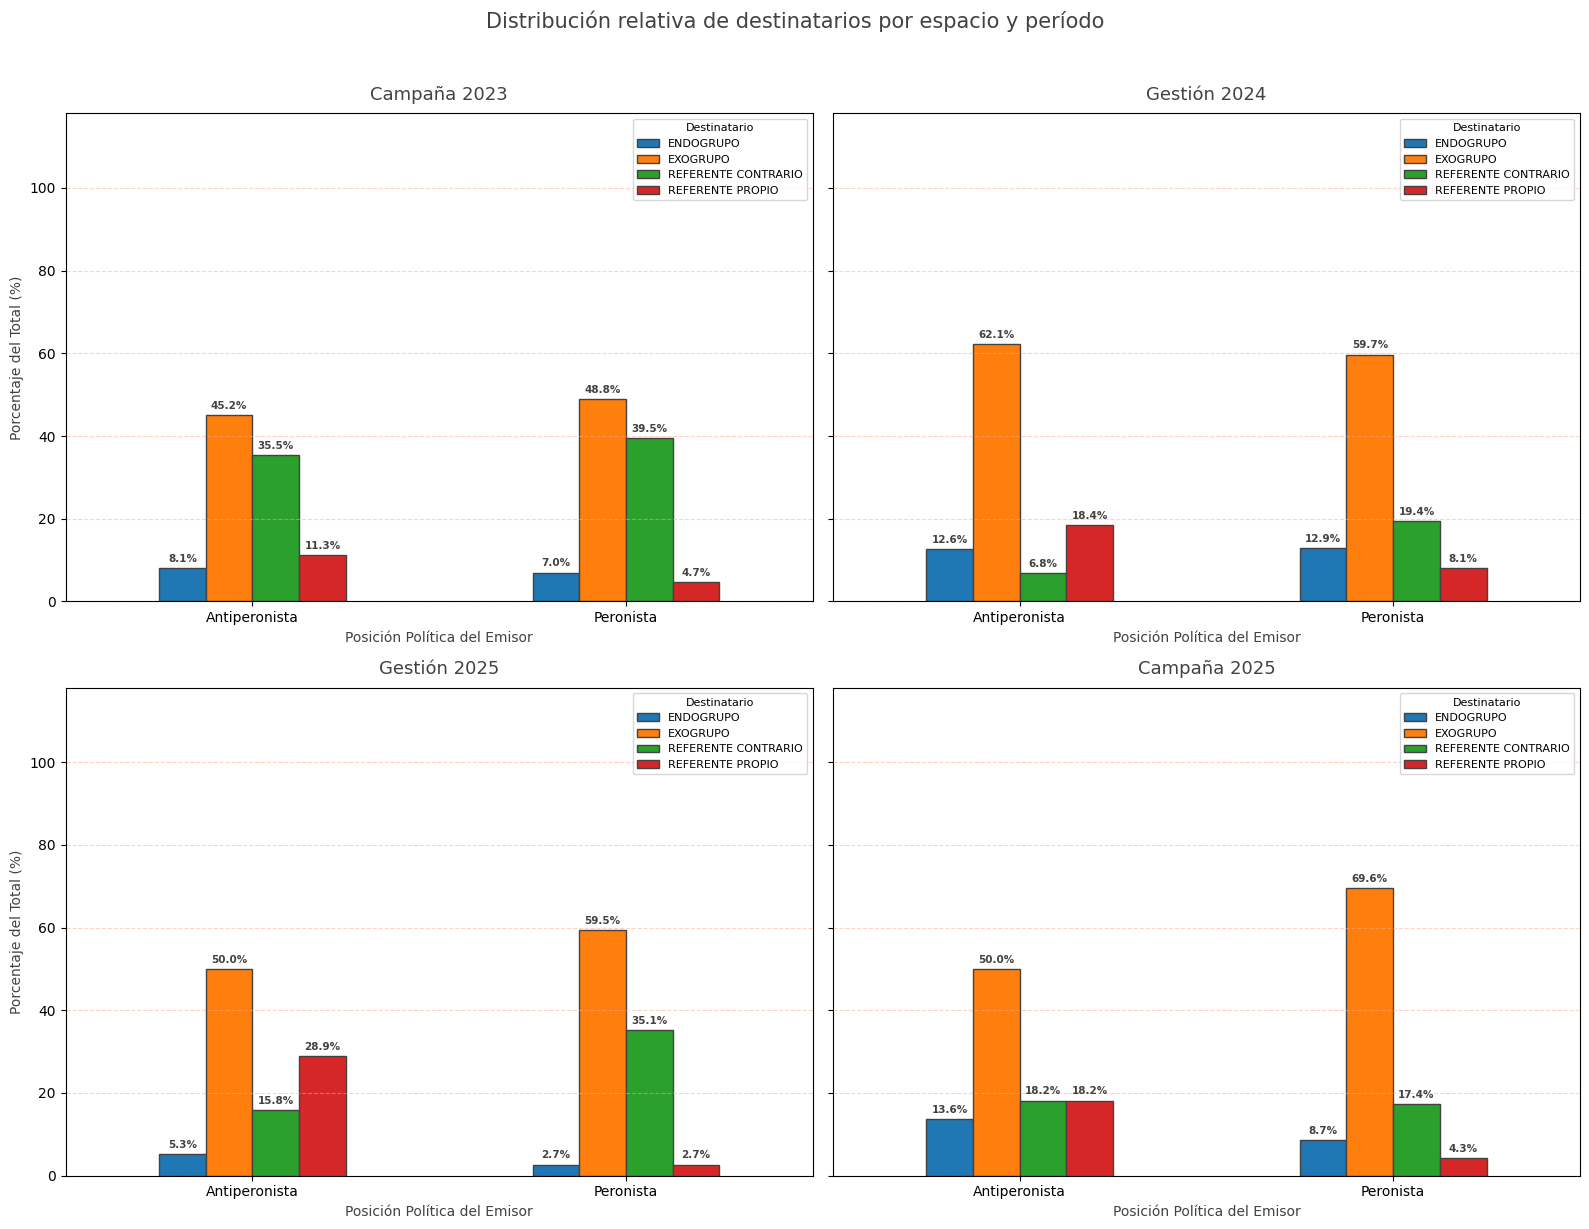

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, 'Campaña 2023'),
    (df_gestion_2024, 'Gestión 2024'),
    (df_gestion_2025, 'Gestión 2025'),
    (df_campana_2025, 'Campaña 2025')
]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Aplanamos para recorrerlos fácilmente con un bucle

columna_destinatario = 'destinatario_de_la_promoción/detracción'

for i, (df_actual, titulo_periodo) in enumerate(periodos):
    ax = axes[i]

    # 1. Copia y preparación del DataFrame para el período actual
    df_plot = df_actual.copy()

    # Limpiamos y unificamos el error tipográfico de "cotnrario" a "contrario"
    if columna_destinatario in df_plot.columns:
        df_plot[columna_destinatario] = (
            df_plot[columna_destinatario]
            .astype(str)
            .str.strip()
            .replace({
                'REFERENTE COTNRARIO': 'REFERENTE CONTRARIO',
                'referente cotnrario': 'referente contrario',
                'Referente cotnrario': 'Referente contrario'
            })
        )

    # Limpiamos y unificamos el error tipográfico de "cotnrario" a "contrario"
    if columna_destinatario in df_plot.columns:
        df_plot[columna_destinatario] = (
            df_plot[columna_destinatario]
            .astype(str)
            .str.strip()
            .replace({
                'w': 'EXOGRUPO'
            })
        )

    # 2. Creamos la tabla cruzada general (Posición vs Destinatario)
    tabla_absoluta = pd.crosstab(
        df_plot['posición'],
        df_plot[columna_destinatario]
    )

    # Creamos la tabla en porcentajes por fila (para que cada posición sume 100%)
    tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

    # 3. Gráfico de barras exclusivamente porcentual para este subplot
    ax_plot = tabla_porcentual.plot(
        kind='bar',
        ax=ax,
        edgecolor='#444140',
        linewidth=1,
        rot=0
    )

    # --- NUEVO: Agregar etiquetas de porcentaje arriba de cada barra ---
    for container in ax.containers:
        heights = [bar.get_height() for bar in container]
        labels = [f'{h:.1f}%' if not pd.isna(h) and h > 0 else '' for h in heights]

        ax.bar_label(
            container,
            labels=labels,
            padding=3,
            fontsize=7.5, # Tamaño ajustado para que entren bien al estar agrupadas
            color='#444140',
            fontweight='bold',
            rotation=0
        )
    # ------------------------------------------------------------------

    ax.set_title(f'{titulo_periodo}', fontsize=13, pad=10, color='#444140')
    ax.set_xlabel('Posición Política del Emisor', fontsize=10, color='#444140')
    ax.set_ylabel('Porcentaje del Total (%)', fontsize=10, color='#444140')
    ax.set_ylim(0, 118)  # Margen cómodo para que las etiquetas no toquen el borde superior
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')

    # Leyenda ordenada
    ax.legend(title='Destinatario', fontsize=8, title_fontsize=8, loc='upper right')

# Título general de la figura
fig.suptitle('Distribución relativa de destinatarios por espacio y período', fontsize=15, color='#444140', y=1.02)

plt.tight_layout()
plt.show()

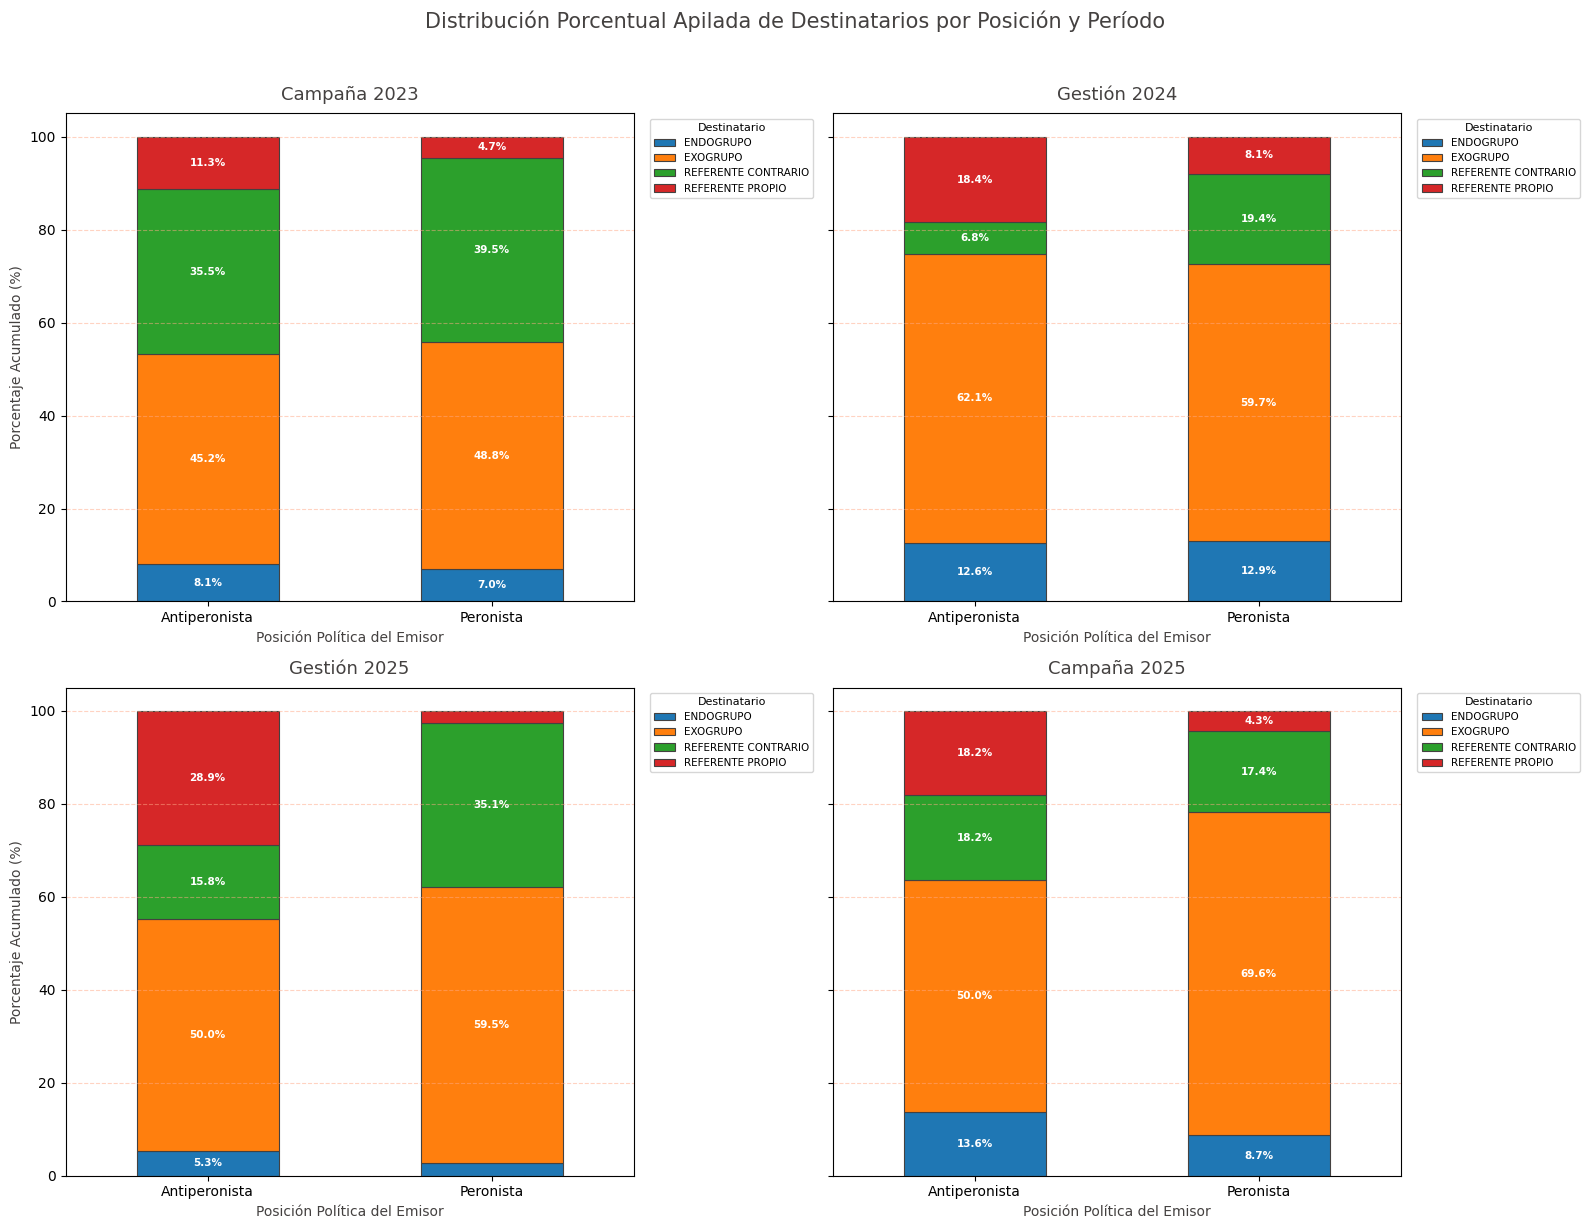

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, 'Campaña 2023'),
    (df_gestion_2024, 'Gestión 2024'),
    (df_gestion_2025, 'Gestión 2025'),
    (df_campana_2025, 'Campaña 2025')
]

# Creamos una figura con una cuadrícula de 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten()  # Aplanamos para recorrerlos fácilmente con un bucle

columna_destinatario = 'destinatario_de_la_promoción/detracción'

for i, (df_actual, titulo_periodo) in enumerate(periodos):
    ax = axes[i]

    # 1. Copia y preparación del DataFrame para el período actual
    df_plot = df_actual.copy()

    # Limpiamos y unificamos el error tipográfico de "cotnrario" a "contrario"
    if columna_destinatario in df_plot.columns:
        df_plot[columna_destinatario] = (
            df_plot[columna_destinatario]
            .astype(str)
            .str.strip()
            .replace({
                'REFERENTE COTNRARIO': 'REFERENTE CONTRARIO',
                'referente cotnrario': 'referente contrario',
                'Referente cotnrario': 'Referente contrario',
                'w': 'EXOGRUPO'
            })
        )

    # 2. Creamos la tabla cruzada general (Posición vs Destinatario)
    tabla_absoluta = pd.crosstab(
        df_plot['posición'],
        df_plot[columna_destinatario]
    )

    # Creamos la tabla en porcentajes por fila (para que cada barra de posición sume exactamente 100%)
    tabla_porcentual = tabla_absoluta.div(tabla_absoluta.sum(axis=1), axis=0) * 100

    # 3. Gráfico de barras apiladas porcentuales para este subplot
    tabla_porcentual.plot(
        kind='bar',
        stacked=True,          # <--- AQUÍ ESTÁ EL CAMBIO CLAVE PARA APILARLAS
        ax=ax,
        edgecolor='#444140',
        linewidth=0.8,
        rot=0
    )

    # --- Opcional: Etiquetas de porcentaje dentro de las porciones apiladas ---
    # En las barras apiladas, bar_label se puede aplicar por contenedor de segmento
    for container in ax.containers:
        # Filtramos etiquetas pequeñas (menores a 4%) para que no se encimen y ensucien el gráfico
        heights = [bar.get_height() for bar in container]
        labels = [f'{h:.1f}%' if not pd.isna(h) and h >= 4.0 else '' for h in heights]

        ax.bar_label(
            container,
            labels=labels,
            label_type='center',  # Ubica el texto en el centro de cada bloque apilado
            fontsize=7.5,
            color='white',        # Texto blanco para destacar sobre el color de la barra
            fontweight='bold'
        )
    # -------------------------------------------------------------------------

    ax.set_title(f'{titulo_periodo}', fontsize=13, pad=10, color='#444140')
    ax.set_xlabel('Posición Política del Emisor', fontsize=10, color='#444140')
    ax.set_ylabel('Porcentaje Acumulado (%)', fontsize=10, color='#444140')
    ax.set_ylim(0, 105)  # Como es apilado al 100%, el límite superior perfecto es 100 o 105
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')

    # Leyenda ordenada y reubicada para que no tape las barras
    ax.legend(title='Destinatario', fontsize=7.5, title_fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')

# Título general de la figura
fig.suptitle('Distribución Porcentual Apilada de Destinatarios por Posición y Período', fontsize=15, color='#444140', y=1.02)

plt.tight_layout()
plt.show()

## Evolución de estrategias discursivas

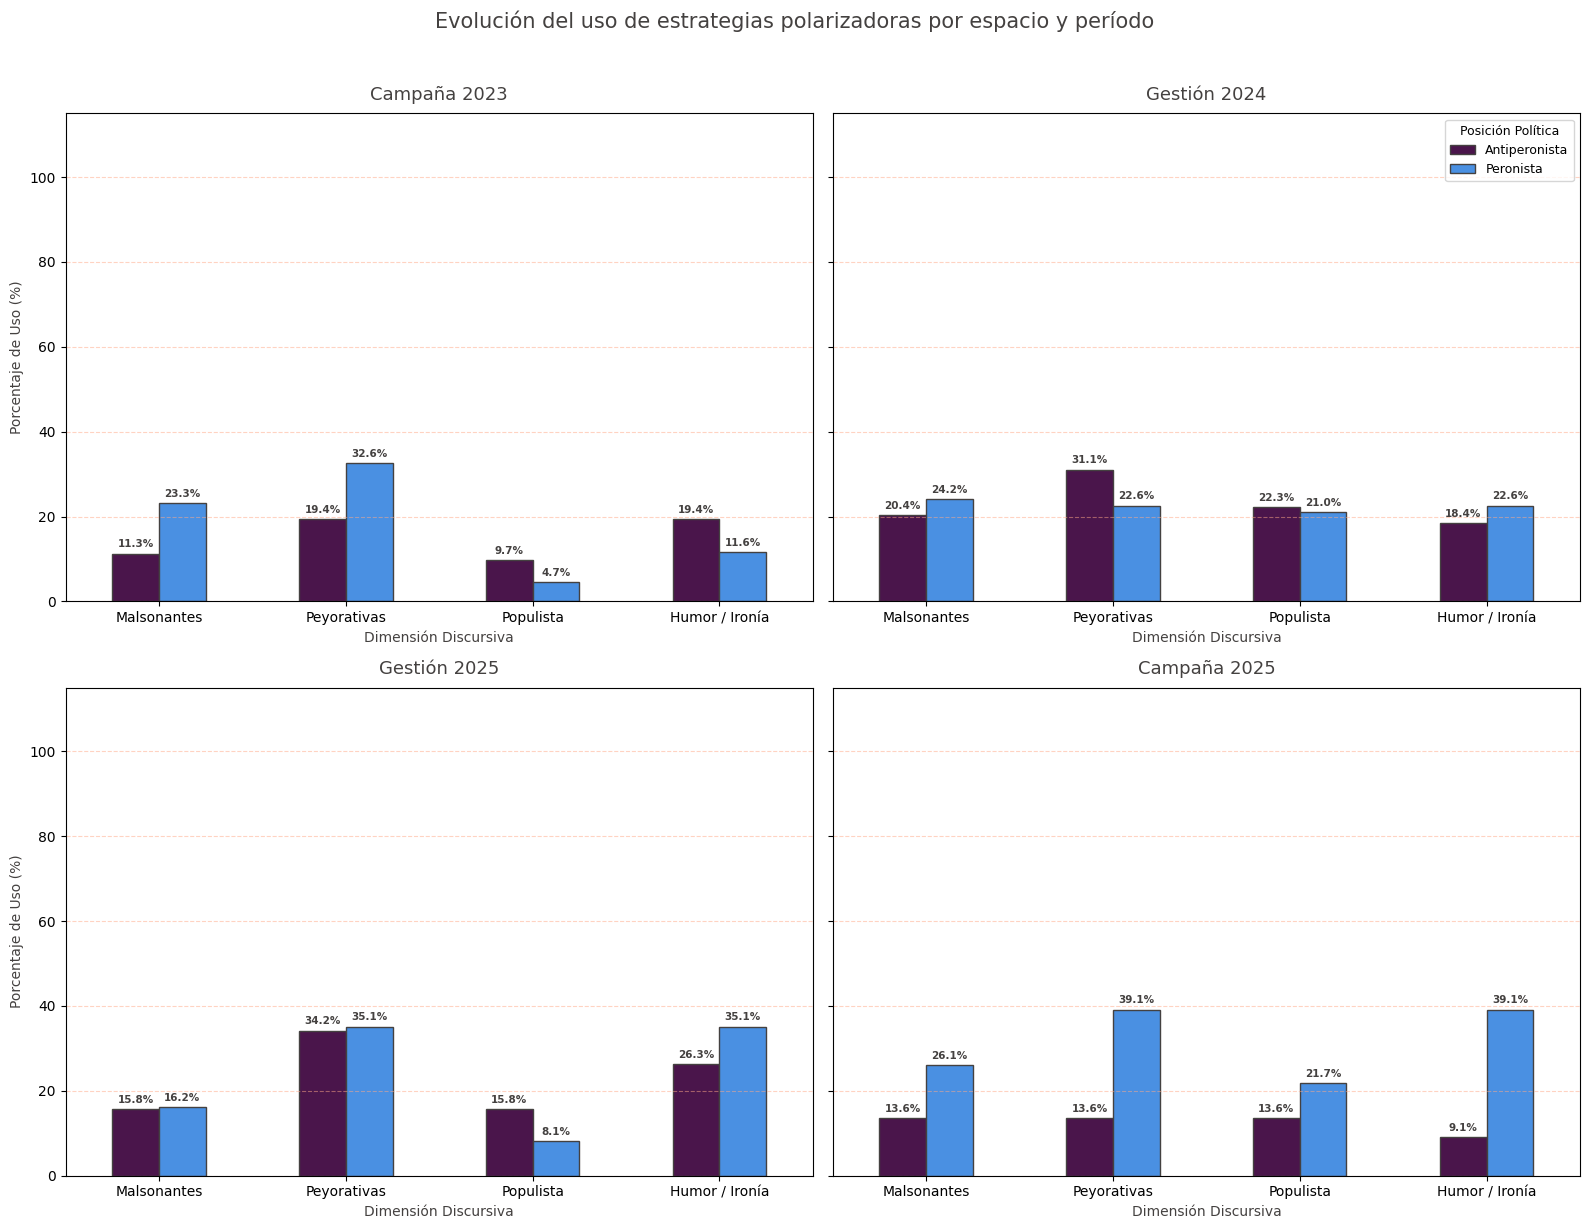

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definimos los dataframes y sus respectivos títulos para los 4 subplots
periodos = [
    (df_campana_2023, 'Campaña 2023'),
    (df_gestion_2024, 'Gestión 2024'),
    (df_gestion_2025, 'Gestión 2025'),
    (df_campana_2025, 'Campaña 2025')
]

# Creamos una figura con una cuadrícula de 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
axes = axes.flatten() # Aplanamos para recorrerlos fácilmente con un bucle

colores_barras = ['#4a154b', '#4a90e2'] # antiperonista / peronista

# Las 4 dimensiones discursivas que querés comparar
dimensiones = [
    'uso_de_palabras_malsonantes',
    'uso_de_etiquetas_peyorativas',
    'uso_de_lenguaje_populista',
    'uso_del_humor_o_ironía'
]

# Nombres más limpios para las etiquetas del eje X
nombres_eje_x = {
    'uso_de_palabras_malsonantes': 'Malsonantes',
    'uso_de_etiquetas_peyorativas': 'Peyorativas',
    'uso_de_lenguaje_populista': 'Populista',
    'uso_del_humor_o_ironía': 'Humor / Ironía'
}

for i, (df_actual, titulo_periodo) in enumerate(periodos):
    ax = axes[i]

    df_plot = df_actual.copy()

    # Aseguramos que las columnas sean numéricas (1 y 0) por si están como booleanas
    for dim in dimensiones:
        if dim in df_plot.columns:
            df_plot[dim] = df_plot[dim].astype(int)

    # Calculamos el porcentaje medio de cada dimensión agrupado por posición política
    # Esto nos da una tabla donde las filas son las dimensiones y las columnas son las posiciones políticas
    tabla_dimensiones = pd.DataFrame()

    if 'posición' in df_plot.columns:
        for posicion, grupo in df_plot.groupby('posición'):
            medias = []
            for dim in dimensiones:
                if dim in grupo.columns:
                    medias.append(grupo[dim].mean() * 100)
                else:
                    medias.append(0)
            tabla_dimensiones[posicion] = medias

        tabla_dimensiones.index = [nombres_eje_x.get(d, d) for d in dimensiones]

    # Si la tabla tiene datos, graficamos
    if not tabla_dimensiones.empty:
        tabla_dimensiones.plot(
            kind='bar',
            ax=ax,
            color=colores_barras,
            edgecolor='#444140',
            linewidth=1,
            legend=(i == 1) # Mostramos la leyenda solo en un subplot para no saturar
        )

        # Agregamos etiquetas de porcentaje arriba de cada barra
        for container in ax.containers:
            heights = [bar.get_height() for bar in container]
            labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]

            ax.bar_label(
                container,
                labels=labels,
                padding=3,
                fontsize=7.5,
                color='#444140',
                fontweight='bold',
                rotation=0
            )

    ax.set_title(f'{titulo_periodo}', fontsize=13, color='#444140', pad=10)
    ax.set_xlabel('Dimensión Discursiva', fontsize=10, color='#444140')
    ax.set_ylabel('Porcentaje de Uso (%)', fontsize=10, color='#444140')

    # Límite superior extendido para que las etiquetas no se corten
    ax.set_ylim(0, 115)

    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5, color='#ffa987')

    # Ajuste de leyenda si corresponde
    if i == 1:
        ax.legend(title='Posición Política', fontsize=9, title_fontsize=9, loc='upper right')

# Título general de la figura
fig.suptitle('Evolución del uso de estrategias polarizadoras por espacio y período', fontsize=15, color='#444140', y=1.02)

plt.tight_layout()
plt.show()

## Evolución emociones exogrupo

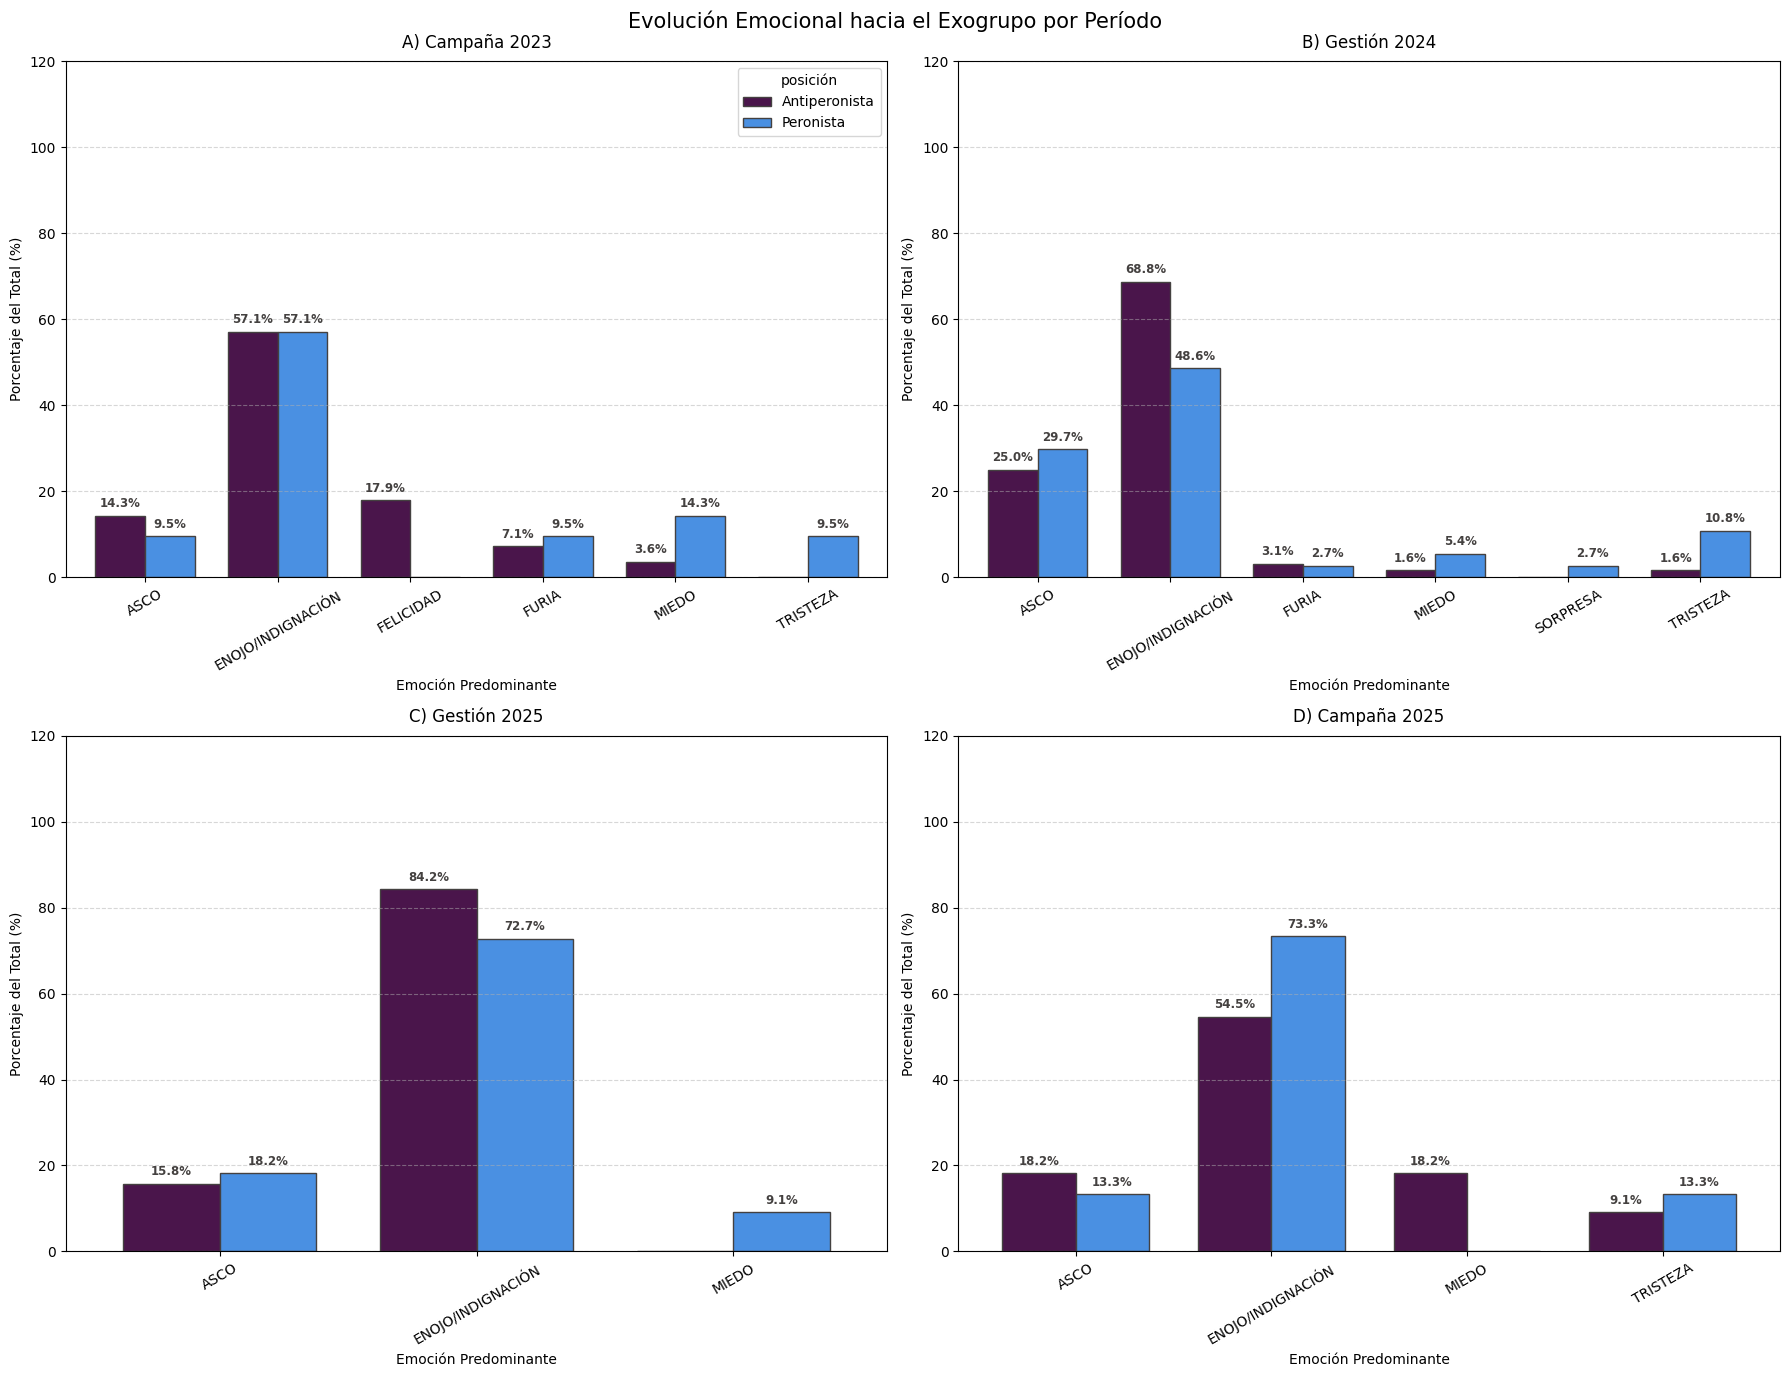

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Definimos los 4 datasets y sus títulos para la evolución del Exogrupo
periodos = [
    (df_campana_2023, 'A) Campaña 2023'),
    (df_gestion_2024, 'B) Gestión 2024'),
    (df_gestion_2025, 'C) Gestión 2025'),
    (df_campana_2025, 'D) Campaña 2025')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()
colores_barras = ['#4a154b', '#4a90e2'] # Antiperonista y Peronista

for i, (df_orig, titulo_periodo) in enumerate(periodos):
    ax = axes_flat[i]
    if df_orig is not None and not df_orig.empty:
        df_plot = df_orig.copy()
        df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
            'ALEGRÍA': 'FELICIDAD', 'Alegría': 'FELICIDAD', 'alegría': 'felicidad'
        })
        col_dest = 'destinatario_de_la_promoción/detracción'
        df_plot[col_dest] = df_plot[col_dest].astype(str).str.strip()

        tabla_emo = pd.pivot_table(df_plot, index='emoción_predominante', columns=[col_dest, 'posición'], aggfunc='size', fill_value=0)
        tabla_pct = tabla_emo.div(tabla_emo.sum(axis=0), axis=1) * 100

        match_col = next((col for col in tabla_pct.columns.levels[0] if 'exogrupo' in str(col).lower()), None)
        if match_col is not None:
            sub_df = tabla_pct[match_col]
            sub_df = sub_df[sub_df.sum(axis=1) > 0]
            if not sub_df.empty:
                sub_df.plot(kind='bar', ax=ax, color=colores_barras, edgecolor='#444140', linewidth=1, legend=(i==0), width=0.75)
                ax.set_title(titulo_periodo, fontsize=12, pad=10)
                ax.set_xlabel('Emoción Predominante', fontsize=10)
                ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
                ax.set_ylim(0, 120)
                ax.set_xlim(-0.6, len(sub_df) - 0.4)

                for container in ax.containers:
                    heights = [bar.get_height() for bar in container]
                    labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]
                    ax.bar_label(container, labels=labels, padding=4, fontsize=8.5, color='#444140', fontweight='bold', rotation=0)

                ax.tick_params(axis='x', rotation=30)
                ax.grid(axis='y', linestyle='--', alpha=0.5)
                continue

    ax.text(0.5, 0.5, 'Sin datos de Exogrupo', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo_periodo, fontsize=12, pad=10)

fig.suptitle('Evolución Emocional hacia el Exogrupo por Período', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

## Evolucion emociones endogrupo

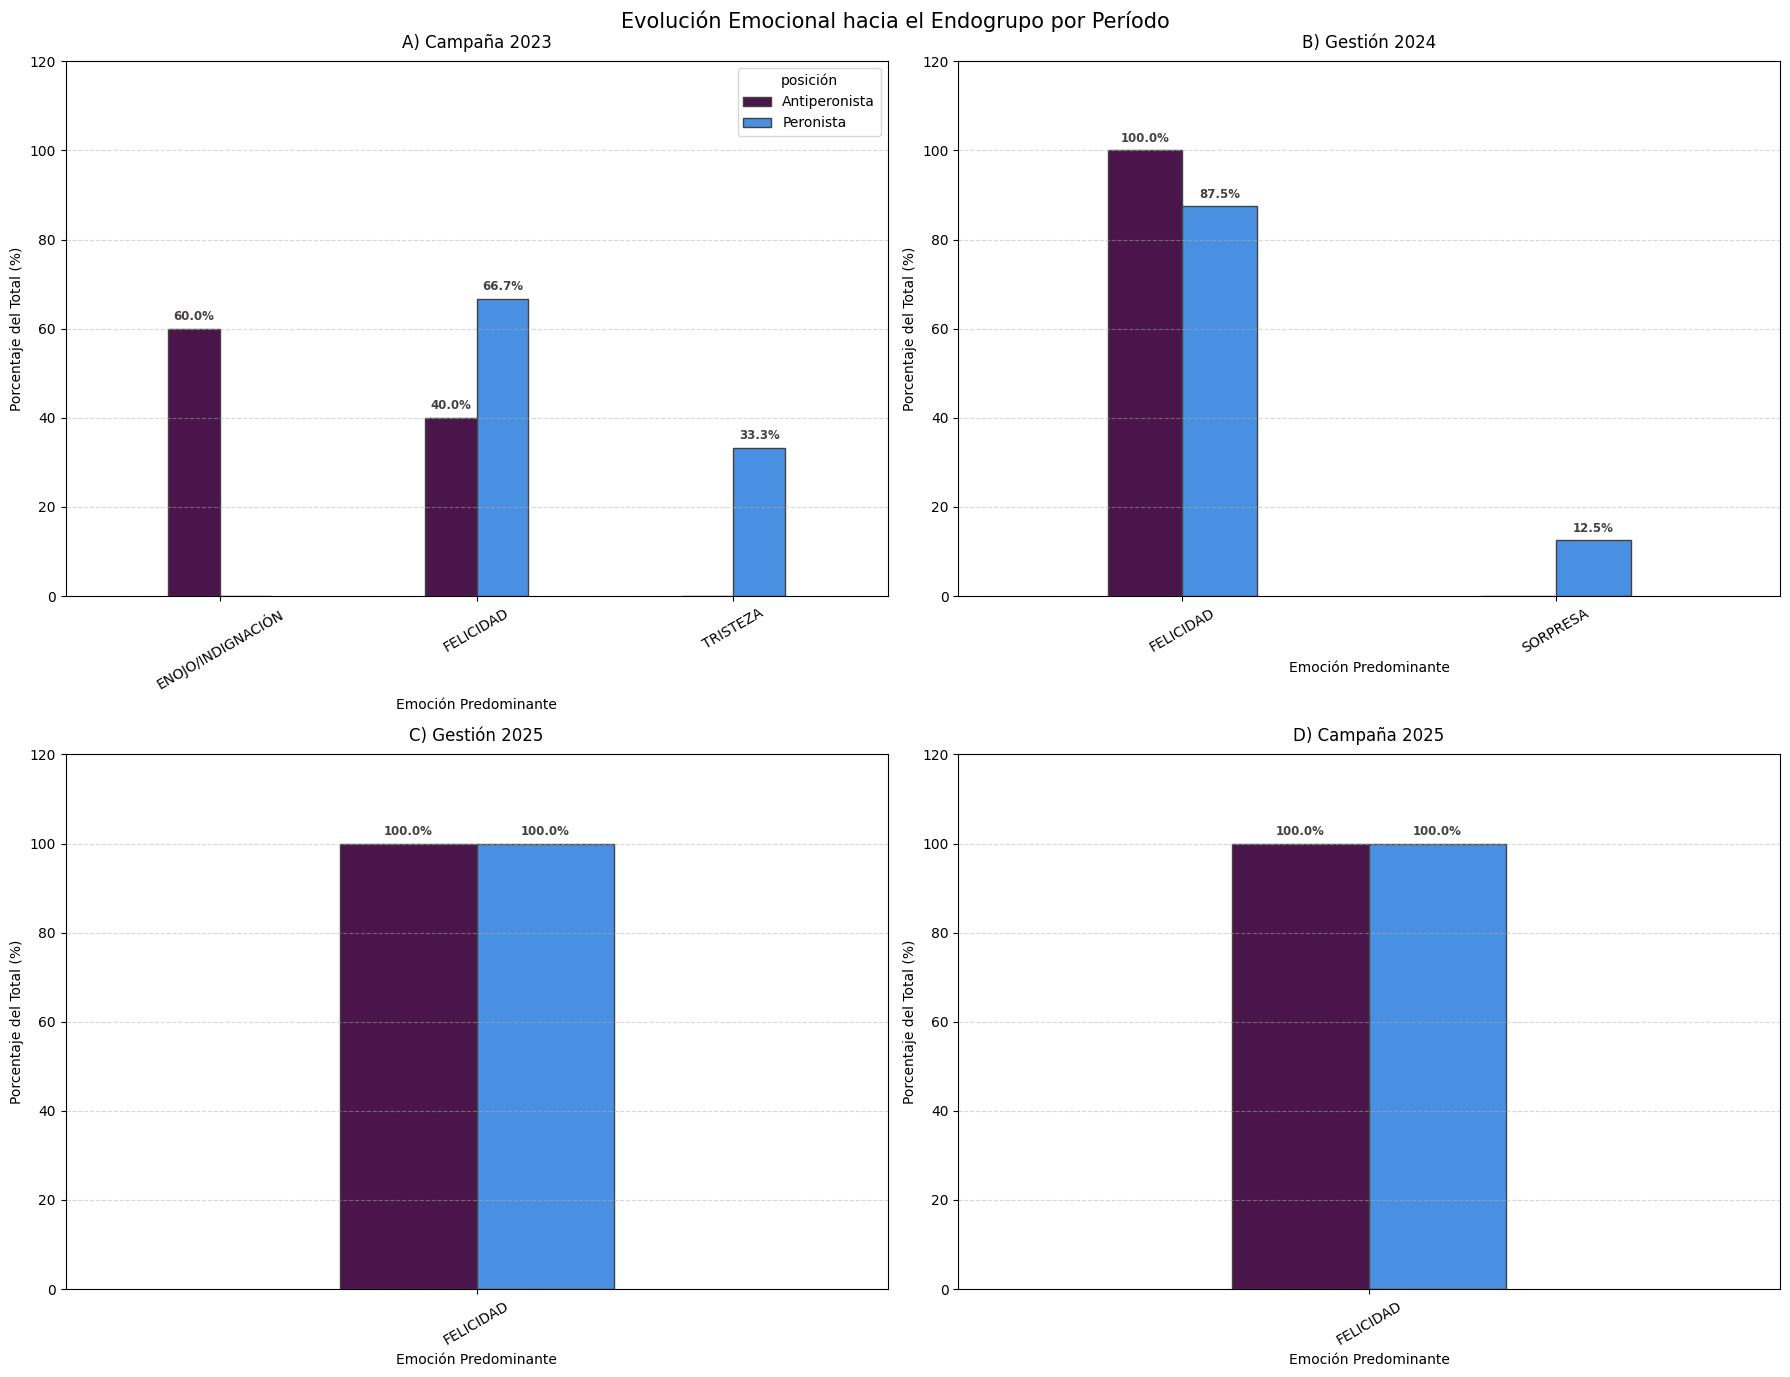

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

periodos = [
    (df_campana_2023, 'A) Campaña 2023'),
    (df_gestion_2024, 'B) Gestión 2024'),
    (df_gestion_2025, 'C) Gestión 2025'),
    (df_campana_2025, 'D) Campaña 2025')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()
colores_barras = ['#4a154b', '#4a90e2']

for i, (df_orig, titulo_periodo) in enumerate(periodos):
    ax = axes_flat[i]
    if df_orig is not None and not df_orig.empty:
        df_plot = df_orig.copy()
        df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
            'ALEGRÍA': 'FELICIDAD', 'Alegría': 'FELICIDAD', 'alegría': 'felicidad'
        })
        col_dest = 'destinatario_de_la_promoción/detracción'
        df_plot[col_dest] = df_plot[col_dest].astype(str).str.strip()

        tabla_emo = pd.pivot_table(df_plot, index='emoción_predominante', columns=[col_dest, 'posición'], aggfunc='size', fill_value=0)
        tabla_pct = tabla_emo.div(tabla_emo.sum(axis=0), axis=1) * 100

        match_col = next((col for col in tabla_pct.columns.levels[0] if 'endogrupo' in str(col).lower()), None)
        if match_col is not None:
            sub_df = tabla_pct[match_col]
            sub_df = sub_df[sub_df.sum(axis=1) > 0]
            if not sub_df.empty:
                # Usamos width=0.4 ya que este solía ser el estilo slim que preferías para endogrupo
                sub_df.plot(kind='bar', ax=ax, color=colores_barras, edgecolor='#444140', linewidth=1, legend=(i==0), width=0.4)
                ax.set_title(titulo_periodo, fontsize=12, pad=10)
                ax.set_xlabel('Emoción Predominante', fontsize=10)
                ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
                ax.set_ylim(0, 120)
                ax.set_xlim(-0.6, len(sub_df) - 0.4)

                for container in ax.containers:
                    heights = [bar.get_height() for bar in container]
                    labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]
                    ax.bar_label(container, labels=labels, padding=4, fontsize=8.5, color='#444140', fontweight='bold', rotation=0)

                ax.tick_params(axis='x', rotation=30)
                ax.grid(axis='y', linestyle='--', alpha=0.5)
                continue

    ax.text(0.5, 0.5, 'Sin datos de Endogrupo', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo_periodo, fontsize=12, pad=10)

fig.suptitle('Evolución Emocional hacia el Endogrupo por Período', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

## Evolucion emociones referente propio

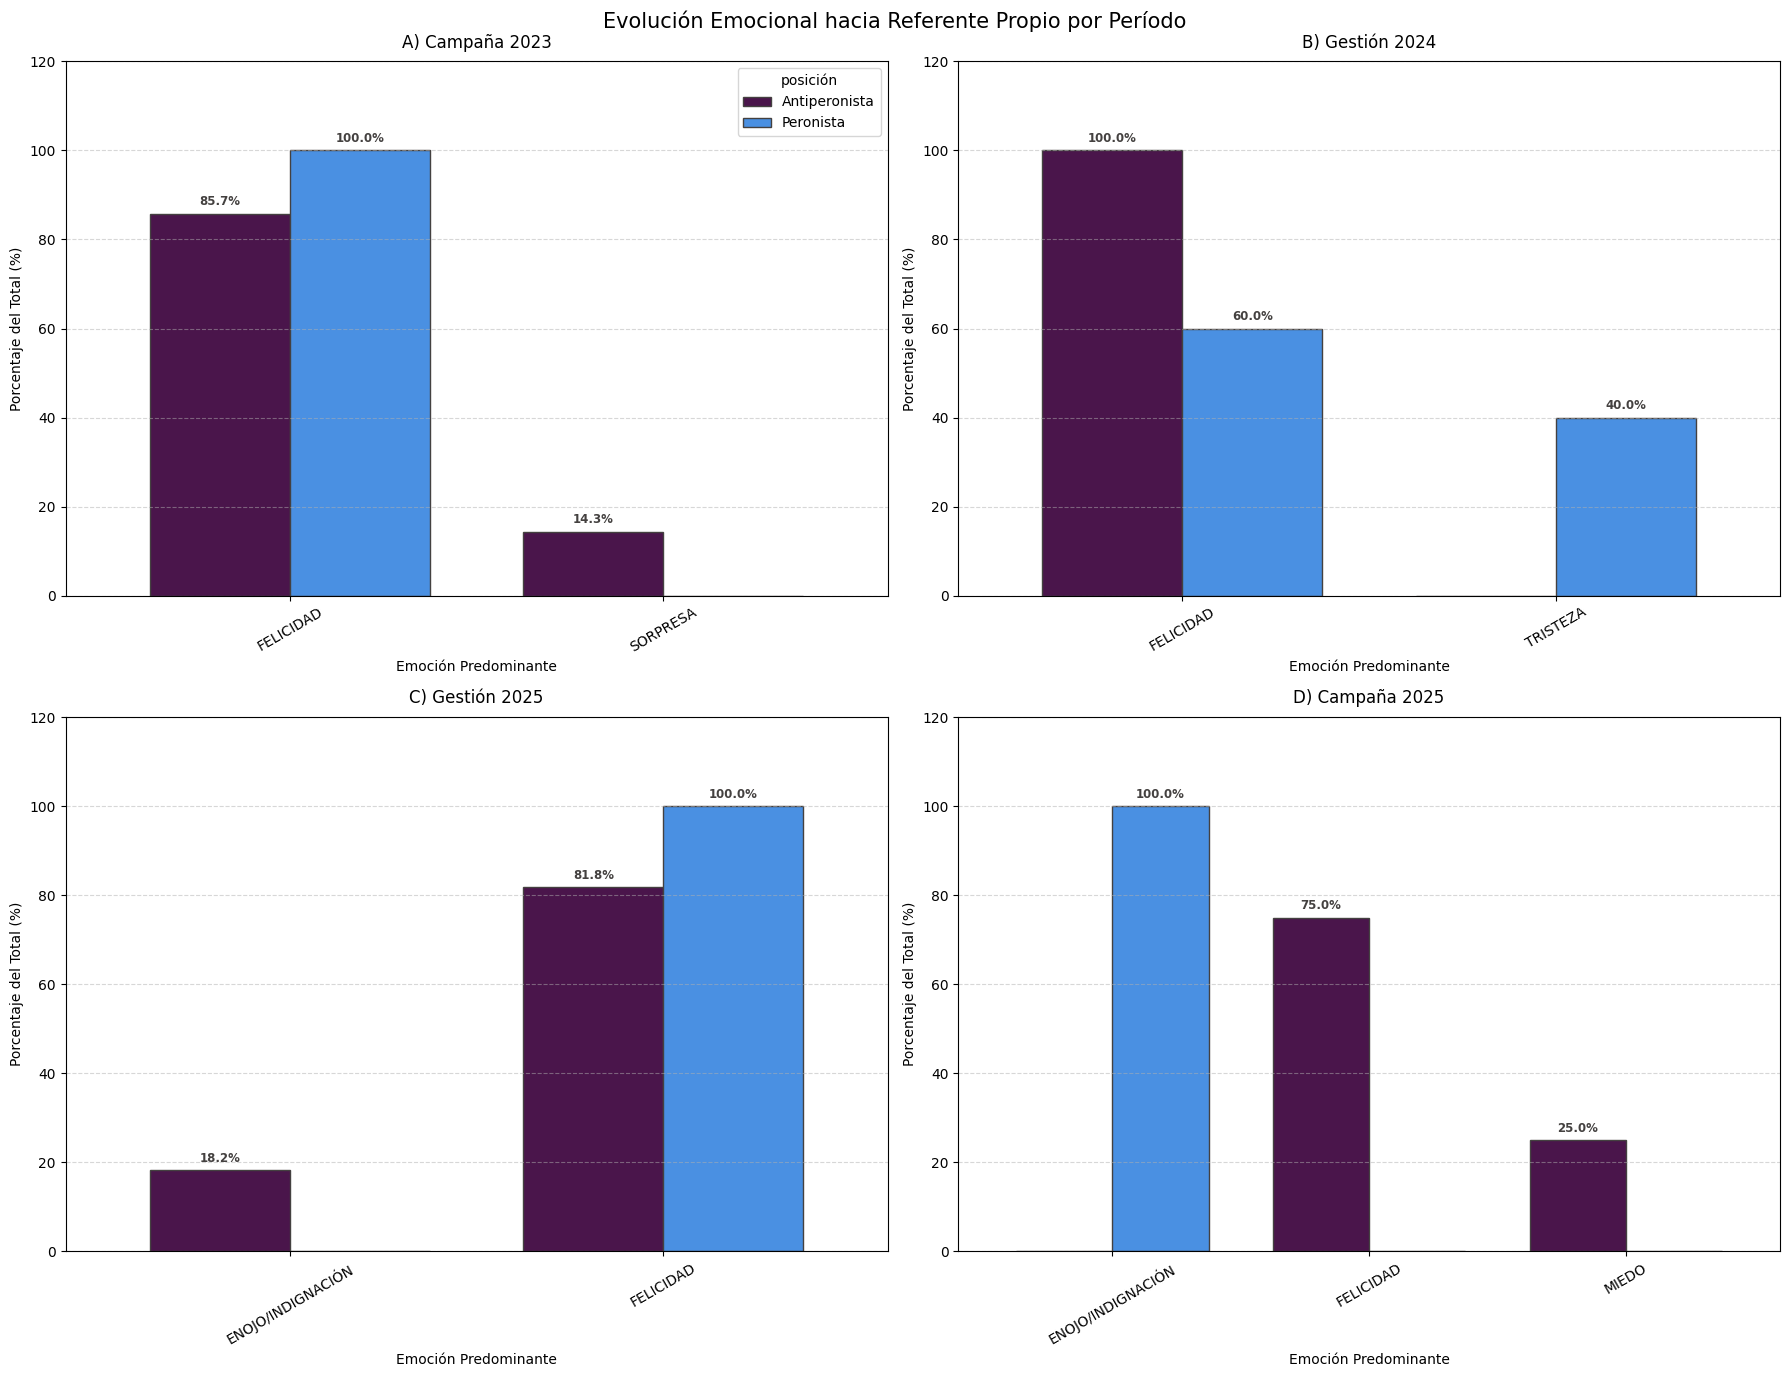

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

periodos = [
    (df_campana_2023, 'A) Campaña 2023'),
    (df_gestion_2024, 'B) Gestión 2024'),
    (df_gestion_2025, 'C) Gestión 2025'),
    (df_campana_2025, 'D) Campaña 2025')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()
colores_barras = ['#4a154b', '#4a90e2']

for i, (df_orig, titulo_periodo) in enumerate(periodos):
    ax = axes_flat[i]
    if df_orig is not None and not df_orig.empty:
        df_plot = df_orig.copy()
        df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
            'ALEGRÍA': 'FELICIDAD', 'Alegría': 'FELICIDAD', 'alegría': 'felicidad'
        })
        col_dest = 'destinatario_de_la_promoción/detracción'
        df_plot[col_dest] = df_plot[col_dest].astype(str).str.strip()

        tabla_emo = pd.pivot_table(df_plot, index='emoción_predominante', columns=[col_dest, 'posición'], aggfunc='size', fill_value=0)
        tabla_pct = tabla_emo.div(tabla_emo.sum(axis=0), axis=1) * 100

        match_col = next((col for col in tabla_pct.columns.levels[0] if 'propio' in str(col).lower()), None)
        if match_col is not None:
            sub_df = tabla_pct[match_col]
            sub_df = sub_df[sub_df.sum(axis=1) > 0]
            if not sub_df.empty:
                sub_df.plot(kind='bar', ax=ax, color=colores_barras, edgecolor='#444140', linewidth=1, legend=(i==0), width=0.75)
                ax.set_title(titulo_periodo, fontsize=12, pad=10)
                ax.set_xlabel('Emoción Predominante', fontsize=10)
                ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
                ax.set_ylim(0, 120)
                ax.set_xlim(-0.6, len(sub_df) - 0.4)

                for container in ax.containers:
                    heights = [bar.get_height() for bar in container]
                    labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]
                    ax.bar_label(container, labels=labels, padding=4, fontsize=8.5, color='#444140', fontweight='bold', rotation=0)

                ax.tick_params(axis='x', rotation=30)
                ax.grid(axis='y', linestyle='--', alpha=0.5)
                continue

    ax.text(0.5, 0.5, 'Sin datos de Referente Propio', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo_periodo, fontsize=12, pad=10)

fig.suptitle('Evolución Emocional hacia Referente Propio por Período', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

## Evolucion referente contrario

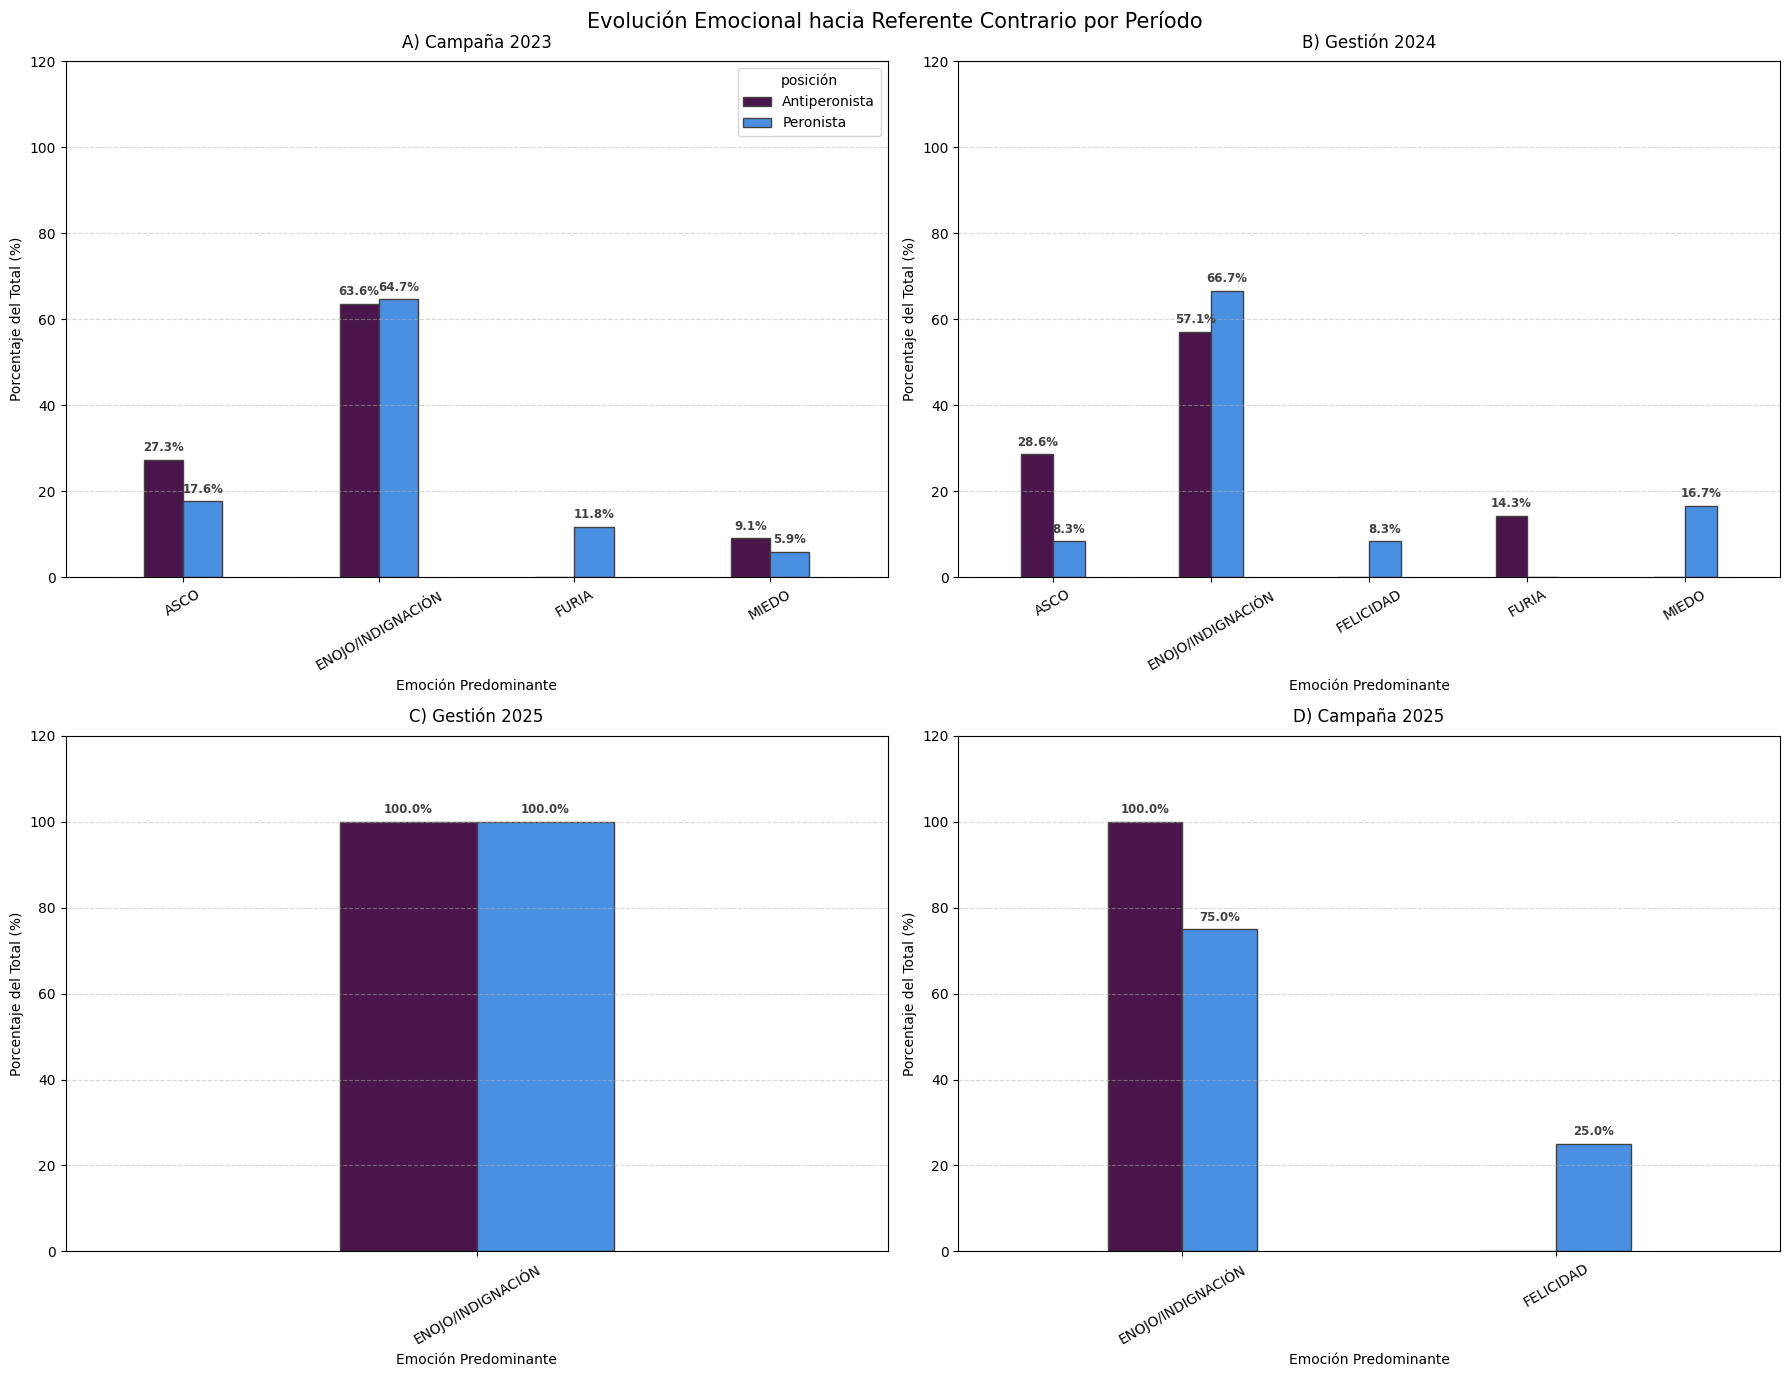

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

periodos = [
    (df_campana_2023, 'A) Campaña 2023'),
    (df_gestion_2024, 'B) Gestión 2024'),
    (df_gestion_2025, 'C) Gestión 2025'),
    (df_campana_2025, 'D) Campaña 2025')
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes_flat = axes.flatten()
colores_barras = ['#4a154b', '#4a90e2']

for i, (df_orig, titulo_periodo) in enumerate(periodos):
    ax = axes_flat[i]
    if df_orig is not None and not df_orig.empty:
        df_plot = df_orig.copy()
        df_plot['emoción_predominante'] = df_plot['emoción_predominante'].replace({
            'ALEGRÍA': 'FELICIDAD', 'Alegría': 'FELICIDAD', 'alegría': 'felicidad'
        })
        col_dest = 'destinatario_de_la_promoción/detracción'
        df_plot[col_dest] = df_plot[col_dest].astype(str).str.strip()

        tabla_emo = pd.pivot_table(df_plot, index='emoción_predominante', columns=[col_dest, 'posición'], aggfunc='size', fill_value=0)
        tabla_pct = tabla_emo.div(tabla_emo.sum(axis=0), axis=1) * 100

        match_col = next((col for col in tabla_pct.columns.levels[0] if 'contrario' in str(col).lower()), None)
        if match_col is not None:
            sub_df = tabla_pct[match_col]
            sub_df = sub_df[sub_df.sum(axis=1) > 0]
            if not sub_df.empty:
                # Usamos width=0.4 para mantener el estilo slim que usabas en este cuadrante
                sub_df.plot(kind='bar', ax=ax, color=colores_barras, edgecolor='#444140', linewidth=1, legend=(i==0), width=0.4)
                ax.set_title(titulo_periodo, fontsize=12, pad=10)
                ax.set_xlabel('Emoción Predominante', fontsize=10)
                ax.set_ylabel('Porcentaje del Total (%)', fontsize=10)
                ax.set_ylim(0, 120)
                ax.set_xlim(-0.6, len(sub_df) - 0.4)

                for container in ax.containers:
                    heights = [bar.get_height() for bar in container]
                    labels = [f'{h:.1f}%' if h > 0 else '' for h in heights]
                    ax.bar_label(container, labels=labels, padding=4, fontsize=8.5, color='#444140', fontweight='bold', rotation=0)

                ax.tick_params(axis='x', rotation=30)
                ax.grid(axis='y', linestyle='--', alpha=0.5)
                continue

    ax.text(0.5, 0.5, 'Sin datos de Referente Contrario', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(titulo_periodo, fontsize=12, pad=10)

fig.suptitle('Evolución Emocional hacia Referente Contrario por Período', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()